# Consensus-Constrained Gaussian Process Modelling of a Multiwavelength Light Curve

This notebook demonstrates the use of the PGMUVI framework to analyse and model a multiwavelength light curve using consensus-constrained Gaussian Process (GP) regression.

The target used throughout this notebook is the carbon-rich asymptotic giant branch star IRAS 10131+3049 (CIT 6), for which photometric observations are available from multiple surveys spanning optical wavelengths. The combined dataset contains measurements obtained through several different filter systems, providing an opportunity to investigate the wavelength dependence of the variability while simultaneously constraining the temporal behaviour.

The workflow presented here proceeds through four main stages:

1. Construction and inspection of the multiwavelength light curve.
2. Identification of candidate periods in individual bands using Lomb-Scargle and autocorrelation analyses.
3. Construction of a consensus period estimate from the subset of bands that provide mutually consistent variability information.
4. Fitting wavelength-dependent Gaussian Process models whose periodic components are constrained by the consensus solution.

Several model variants are explored, beginning with a standard wavelength-dependent spectral-mixture GP and progressing to a bespoke model that introduces an additional wavelength-local residual component. The purpose of these experiments is not only to obtain a good fit to the data, but also to understand the circumstances under which the model succeeds or fails, and what these successes and failures reveal about the underlying variability.

Throughout the notebook, all period determination is performed internally in frequency space. Periods are reported for interpretability, but consensus construction and GP constraints are derived from frequencies in order to avoid the pathological behaviour that can arise when averaging or clustering directly in period space.


## Imports and Configuration

The following cell imports the packages required for the analysis and defines a small number of configuration parameters that will be used throughout the notebook.

Most of the experiments shown below differ only in the choice of Gaussian Process model. Keeping the configuration in a single location makes it easier to reproduce results and ensures that differences between fits can be attributed to model choices rather than changes in optimisation settings.

Unless otherwise noted, all Gaussian Process fits use the same training configuration, consensus settings, and optimisation parameters. This allows the behaviour of the various model architectures to be compared directly.


In [1]:
# ---------------------------------------------------------------------
# Install PGMUVI if required
# ---------------------------------------------------------------------

try:
    import pgmuvi
except (ImportError, ModuleNotFoundError):
    # !pip -q install pgmuvi
    !pip -q install git+https://github.com/ICSM/pgmuvi.git@integration-consensus-test
    import pgmuvi

# ---------------------------------------------------------------------
# Standard library
# ---------------------------------------------------------------------

from pathlib import Path
import json
import warnings

# ---------------------------------------------------------------------
# Third-party packages
# ---------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# PGMUVI
# ---------------------------------------------------------------------

from pgmuvi.lightcurve import Lightcurve, ConsensusFitError

# ---------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ---------------------------------------------------------------------
# Notebook configuration
# ---------------------------------------------------------------------

OUTPUT_DIR = Path("consensus_fit_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_NAME = "IRAS 10131+3049 (CIT 6)"

# ---------------------------------------------------------------------
# Consensus-fit configuration
# ---------------------------------------------------------------------

TRAINING_ITER = 500
NUM_MIXTURES = 1

CONSTRAINT_SET = "LPV"
PRIOR_SET = "LPV"

MIN_PERIOD_DAYS = 20.0
MAX_PERIOD_DAYS = 4500.0

MIN_FREQUENCY = 1.0 / MAX_PERIOD_DAYS
MAX_FREQUENCY = 1.0 / MIN_PERIOD_DAYS

MIN_CONSENSUS_INLIERS = 2

USE_GP_VALIDATION = False

# ---------------------------------------------------------------------
# Optimizer configuration
# ---------------------------------------------------------------------

LR = 0.05
GRID_SIZE = 2000
CUDA = False

print(f"Source: {SOURCE_NAME}")
print(f"Training iterations: {TRAINING_ITER}")
print(f"Spectral-mixture components: {NUM_MIXTURES}")
print(f"Constraint set: {CONSTRAINT_SET}")
print(f"Consensus inliers required: {MIN_CONSENSUS_INLIERS}")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 13.5 MB/s eta 0:00:00
Source: IRAS 10131+3049 (CIT 6)
Training iterations: 500
Spectral-mixture components: 1
Constraint set: LPV
Consensus inliers required: 2


## Baseline Consensus-Constrained Fit

We begin with the simplest wavelength-dependent model considered in this notebook: a single-component spectral-mixture Gaussian Process coupled to wavelength through a smooth radial-basis-function (RBF) kernel.

The purpose of this first fit is to establish a baseline against which more complicated models can be compared. The fit uses the automatic consensus workflow implemented in PGMUVI. Candidate periods are first identified independently in each wavelength band using Lomb-Scargle and autocorrelation analyses. Bands that fail the sampling-quality requirements or do not provide mutually consistent variability information are excluded from the consensus calculation. The surviving bands are then used to construct a consensus frequency range that constrains the periodic component of the Gaussian Process.

Only a single spectral-mixture component is used in this fit. Consequently, the model is forced to describe the variability using one dominant timescale shared across all wavelengths. Any systematic failures therefore provide useful information about limitations of the model architecture rather than ambiguity introduced by multiple periodic components.

The cell below performs the fit and displays both the multiwavelength light-curve reconstruction and the corresponding period summary.


#### Let's try a 1-component `2DWavelengthDependent` model, fit it, and display the results.

/usr/local/lib/python3.12/dist-packages/pgmuvi/preprocess/quality.py:286: UserWarning: median_cadence is zero (many duplicate timestamps present). Falling back to the mean of positive gaps only for nyquist_period, nyquist_frequency, and duty_cycle; results may not be robust.
  metrics = compute_sampling_metrics(t, y, yerr)
/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:1417: UserWarning: Skipping band λ=0.4849115014076233 due to poor temporal sampling: Too few points: 12 < 15, Large gap: 702.00 (94.9% of baseline) > 30% threshold, Lightcurve contains large numbers of points with identical timestamps. Determining sampling quality using mean cadence instead of median; result may not be robust.
  return cls(xdata=x, ydata=y, yerr=yerr, **kwargs)
/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:1417: UserWarning: Skipping band λ=0.6201199889183044 due to poor temporal sampling: Large gap: 698.00 (47.7% of baseline) > 30% threshold
  return cls(xdata=x, ydata=y, ye

[consensus] accepted bands: ['KELT/OSN_Johnson.Cousins_R3_0', 'ASAS_SN/Misc_APASS.V', 'ZTF/Palomar_ZTF.r']
[consensus] rejected bands: ['KELT/OSN_Johnson.Cousins_R3_1', 'GAIA_DR3/GAIA_GAIA3.Gbp', 'GAIA_DR3/GAIA_GAIA3.G', 'GAIA_DR3/GAIA_GAIA3.Grp', 'ZTF/Palomar_ZTF.g']
[consensus] band=KELT/OSN_Johnson.Cousins_R3_0 dominant_period=585.686 dominant_frequency=0.0017074 acf_status=agreement harmonic_order=1
[consensus] band=KELT/OSN_Johnson.Cousins_R3_1 rejected: ls_acf_disagreement
[consensus] band=ASAS_SN/Misc_APASS.V dominant_period=597.097 dominant_frequency=0.00167477 acf_status=agreement harmonic_order=1
[consensus] band=GAIA_DR3/GAIA_GAIA3.Gbp rejected: duty_cycle (0.0151 < 0.124)
[consensus] band=GAIA_DR3/GAIA_GAIA3.G rejected: duty_cycle (0.0149 < 0.124)
[consensus] band=GAIA_DR3/GAIA_GAIA3.Grp rejected: duty_cycle (0.0151 < 0.124)
[consensus] band=ZTF/Palomar_ZTF.g rejected: ls_acf_disagreement
[consensus] band=ZTF/Palomar_ZTF.r dominant_period=576.983 dominant_frequency=0.001733

/usr/local/lib/python3.12/dist-packages/gpytorch/likelihoods/noise_models.py:150: NumericalWarning: Very small noise values detected. This will likely lead to numerical instabilities. Rounding small noise values up to 1e-06.
  warnings.warn(
100%|██████████| 500/500 [01:36<00:00,  5.17it/s]
/usr/local/lib/python3.12/dist-packages/gpytorch/likelihoods/gaussian_likelihood.py:350: GPInputWarning: You have passed data through a FixedNoiseGaussianLikelihood that did not match the size of the fixed noise, *and* you did not specify noise. This is treated as a no-op.
  warnings.warn(


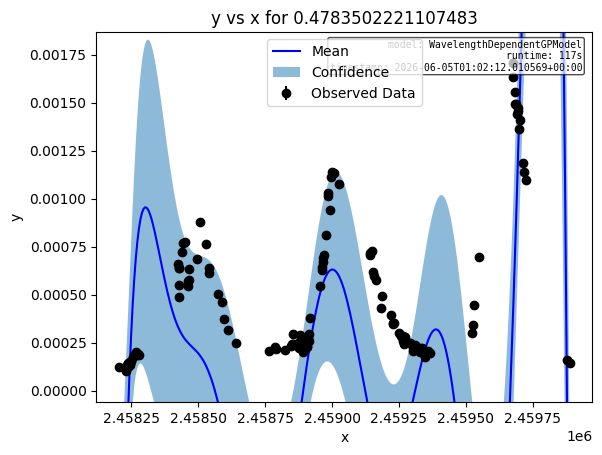

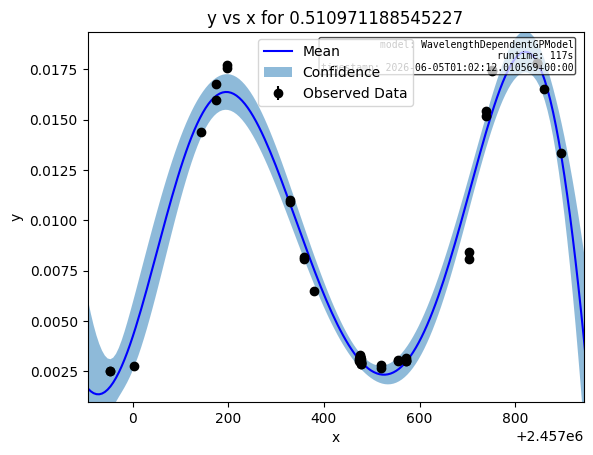

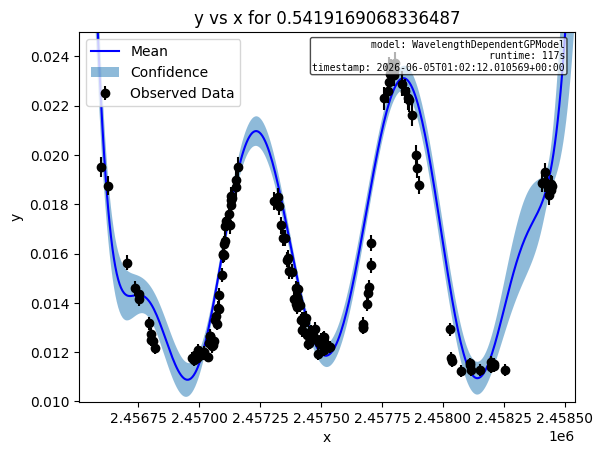

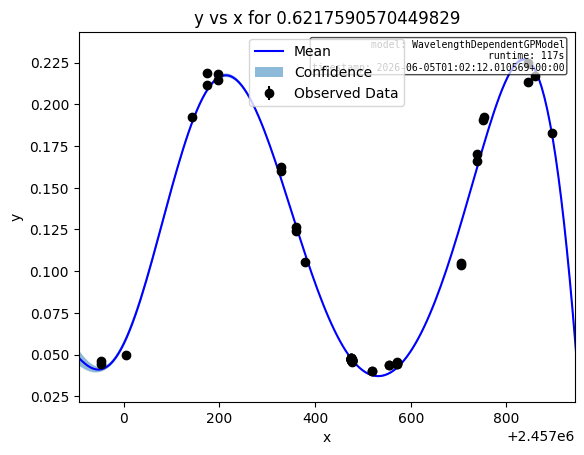

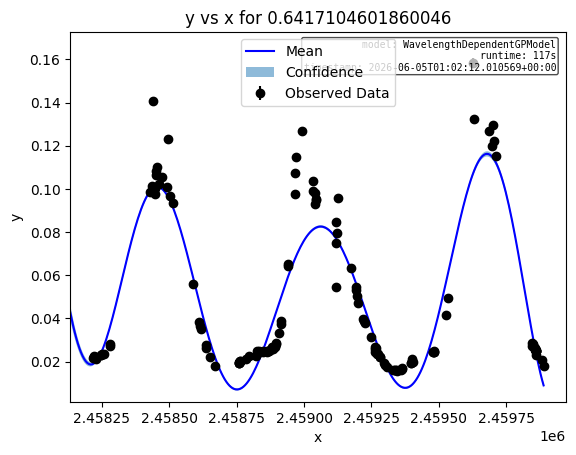

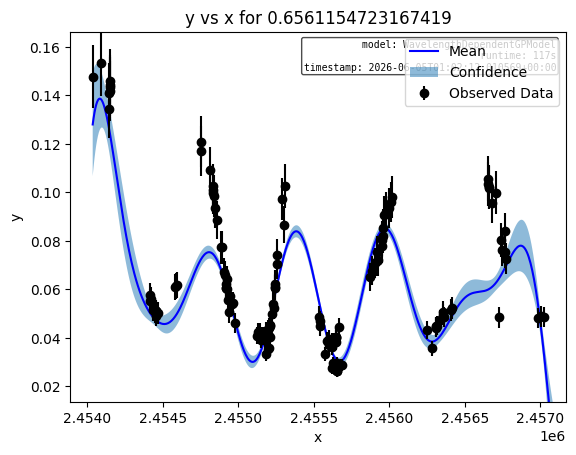

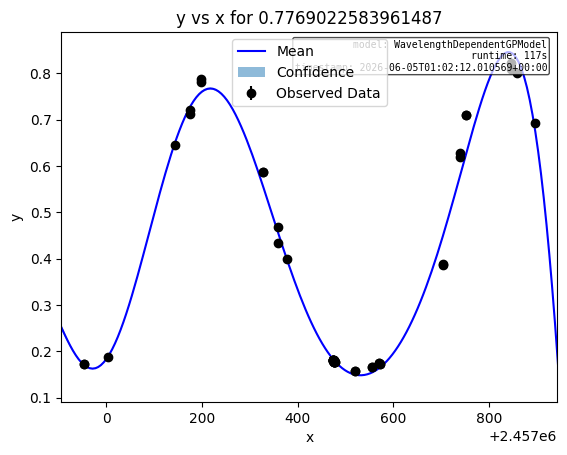

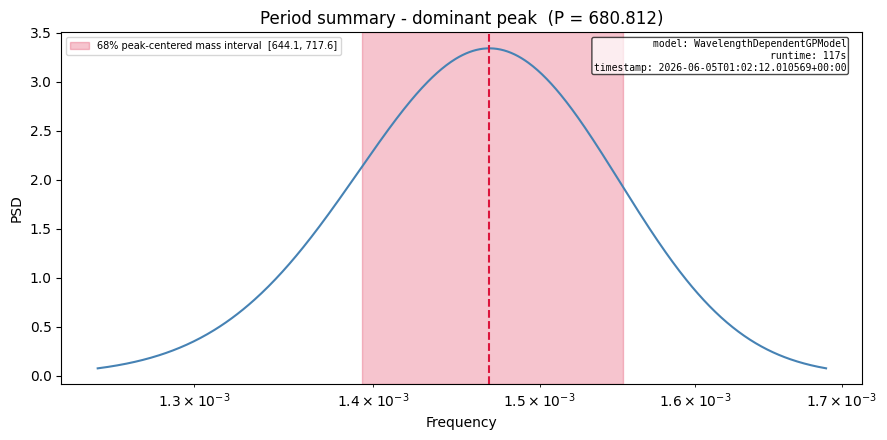

PERIOD SUMMARY
  Model name          : N/A
  Method              : spectral_mixture_psd_peak
  Backend             : separable_2d
  Kernel family       : ProductKernel
  Time-kernel family  : SpectralMixtureKernel
  Stochastic bg       : False
  Interval definition : peak_centered_68pct_mass_interval
  Dominant period     : 680.812
  Dominant frequency  : 0.00146883
  Peaks detected      : 1
  Peaks analyzed      : 1
  Peaks requested     : N/A
  Notes               : Separable 2D model (separable_2d backend): period summary derived from the time kernel (SpectralMixtureKernel) only.  The wavelength kernel does not contribute to this period determination.  Spectral-mixture model (spectral_mixture backend).  Periods are derived from peaks of the SUMMED PSD on a frequency grid — this is the literature-comparable output.  The component periods/frequencies listed in the kernel component diagnostics section are direct kernel hyperparameter values and are for diagnostic purposes only; they ar

In [2]:
# lc_2d = Lightcurve.from_csv("10131+3049.csv", max_samples_per_band=200, max_samples=1000, check_sampling=True)
lc_2d = Lightcurve.from_csv("10131+3049.csv", max_samples_per_band=150, max_samples=1000, check_sampling=True)
lc_2d.double()
fit_result = lc_2d.fit(
    # model="2D",
    model="2DWavelengthDependent",
    time_kernel_type="spectral_mixture",
    wavelength_kernel_type="rbf",
    mean_module="quad",
    training_iter=TRAINING_ITER,
    num_mixtures=NUM_MIXTURES,
    constraint_set=CONSTRAINT_SET,
    cuda=CUDA,
    use_mls_init=False,
    use_best_band_init=False,
    fit_strategy="consensus",
    use_acf=True,
    use_gp_validation=False,
    min_consensus_inliers=3,
    outlier_sigma=2.0,
    consensus_dedup_rtol=0.02,
    constrain_consensus=True,
    consensus_width_factor=1.0,
    consensus_frequency_k=1.0,
    consensus_scale_max_factor=0.05,
    lr=0.05,
    stopavg=30,
    verbose=True,
)
lc_2d.plot(annotate_provenance=True, provenance_location="upper right",)
lc_2d.plot_period_summary(annotate_provenance=True, provenance_location="upper right", log_y=False)
period_summary = lc_2d.get_period_summary()
print(period_summary.to_text(max_peaks_to_show=2))
print(lc_2d.fit_history_to_text())
print(lc_2d.print_fit_history_summary(print_summary=False))
report = lc_2d.generate_reproducibility_report(
    latest_only=False,
    include_history=True,
    include_configurations=True,
    include_environment=True,
)
print(report)


## Interpretation of the Baseline Fit

The consensus workflow identifies a dominant variability timescale close to 600 days. The period summary shows that the accepted bands produce broadly consistent frequency estimates, allowing a narrow consensus frequency range to be imposed on the Gaussian Process model. As a result, the fitted spectral-mixture component remains tightly constrained near the common period preferred by the majority of the light curves.

The resulting fit successfully reproduces the overall variability pattern in most wavelength bands. The inferred oscillations track the observed maxima and minima reasonably well, and the recovered period is consistent with the variability timescale suggested by the independent Lomb-Scargle and autocorrelation analyses.

The most obvious deficiency occurs in the shortest-wavelength band near 0.48 μm. While the model still reproduces the broad variability pattern, the fit quality is visibly worse than in the neighbouring bands. In particular, the predicted amplitude and phase structure do not align with the observations as well as they do at longer wavelengths. The associated uncertainty envelope is also broader.

At first glance, such behaviour could be interpreted as evidence for a different period at short wavelengths. However, subsequent diagnostics presented later in this notebook show that the accepted-band periodograms overlap strongly near the consensus solution. The discrepancy therefore appears to arise primarily from wavelength-dependent amplitude and shape behaviour rather than from a genuinely different dominant period.

This behaviour is not entirely unexpected. The shortest-wavelength band lies at the edge of the wavelength range covered by the data. Wavelength-dependent Gaussian Process models are generally best constrained in regions where neighbouring bands exist on both sides. At the boundary of the wavelength domain, the model has less information available to constrain how variability properties should evolve with wavelength, making edge bands more susceptible to modelling errors.

The baseline fit therefore establishes two important conclusions. First, a single consensus-constrained periodic component is sufficient to explain the dominant variability seen across most wavelengths. Second, the shortest-wavelength band represents the principal failure mode of the model and motivates the more flexible experiments explored in the following sections.


## Introducing a Second Spectral-Mixture Component

The baseline model forces all variability to be described by a single spectral-mixture component. Although this approach successfully reproduces the dominant behaviour of most bands, it leaves open the possibility that additional structure may be present in the light curve.

To investigate this possibility, we now repeat the fit using two spectral-mixture components. The consensus-derived frequency constraint is still applied, but the model is given additional freedom to distribute variability power between multiple components. In principle, this can allow the GP to represent harmonic structure, quasi-periodic behaviour, long secondary periods, or other departures from a purely single-period description.

It is important to emphasize that introducing a second component does not automatically imply the existence of a second astrophysical period. Gaussian Process models can use additional components simply to obtain a more flexible description of the observed variability. Consequently, the primary objective of this experiment is not to detect a new period, but rather to determine whether the quality of the fit improves sufficiently to justify the increased model complexity.

The following fit therefore serves as a direct comparison with the single-component solution. Any improvement must be evaluated against the additional degrees of freedom introduced by the second spectral-mixture component.


/usr/local/lib/python3.12/dist-packages/pgmuvi/preprocess/quality.py:286: UserWarning: median_cadence is zero (many duplicate timestamps present). Falling back to the mean of positive gaps only for nyquist_period, nyquist_frequency, and duty_cycle; results may not be robust.
  metrics = compute_sampling_metrics(t, y, yerr)
/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:1417: UserWarning: Skipping band λ=0.4849115014076233 due to poor temporal sampling: Too few points: 12 < 15, Large gap: 702.00 (94.9% of baseline) > 30% threshold, Lightcurve contains large numbers of points with identical timestamps. Determining sampling quality using mean cadence instead of median; result may not be robust.
  return cls(xdata=x, ydata=y, yerr=yerr, **kwargs)
/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:1417: UserWarning: Skipping band λ=0.6201199889183044 due to poor temporal sampling: Large gap: 698.00 (47.7% of baseline) > 30% threshold
  return cls(xdata=x, ydata=y, ye

[multicomp] band=KELT/OSN_Johnson.Cousins_R3_0 wavelength=0.6561154723167419 n_candidates=3
  rank=0 freq=0.00164044 period=609.592 power=0.5366 prom=0.5362 sig=True
  rank=1 freq=0.00231001 period=432.899 power=0.3143 prom=0.1492 sig=True
  rank=2 freq=0.00438567 period=228.015 power=0.2266 prom=0.2233 sig=True
[multicomp] band=KELT/OSN_Johnson.Cousins_R3_1 wavelength=0.6561154723167419 n_candidates=3
  rank=0 freq=0.00162293 period=616.17 power=0.8495 prom=0.6878 sig=True
  rank=1 freq=0.0043163 period=231.68 power=0.5185 prom=0.4811 sig=True
  rank=3 freq=0.00203729 period=490.847 power=0.4001 prom=0.04111 sig=True
[multicomp] band=ASAS_SN/Misc_APASS.V wavelength=0.5419169068336487 n_candidates=3
  rank=0 freq=0.00167477 period=597.097 power=0.8 prom=0.7825 sig=True
  rank=1 freq=0.00448406 period=223.012 power=0.3272 prom=0.3217 sig=True
  rank=3 freq=0.00307942 period=324.737 power=0.07292 prom=0.0616 sig=False
[multicomp] band=GAIA_DR3/GAIA_GAIA3.Gbp rejected (quality): duty_cycl

100%|██████████| 500/500 [01:34<00:00,  5.27it/s]
/usr/local/lib/python3.12/dist-packages/gpytorch/likelihoods/gaussian_likelihood.py:350: GPInputWarning: You have passed data through a FixedNoiseGaussianLikelihood that did not match the size of the fixed noise, *and* you did not specify noise. This is treated as a no-op.
  warnings.warn(


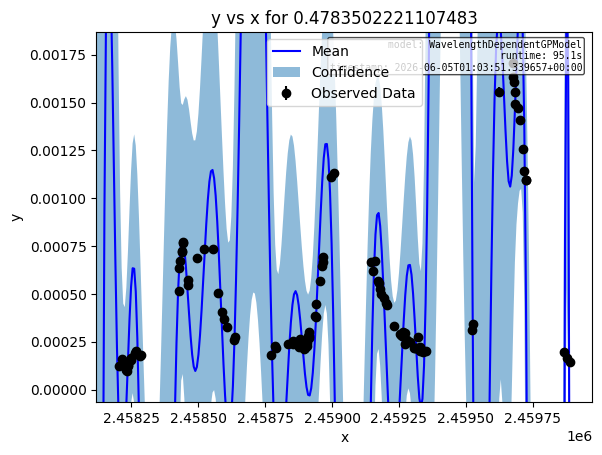

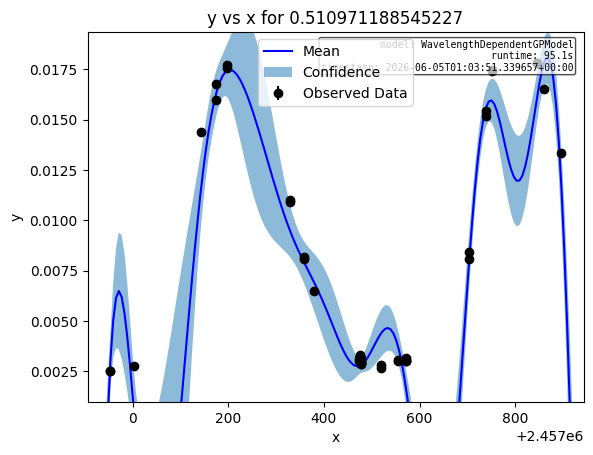

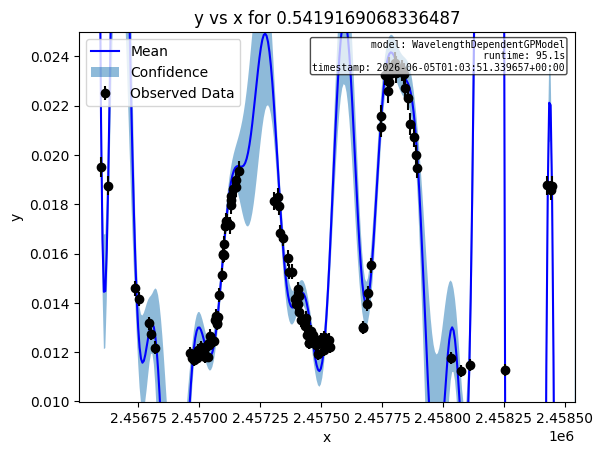

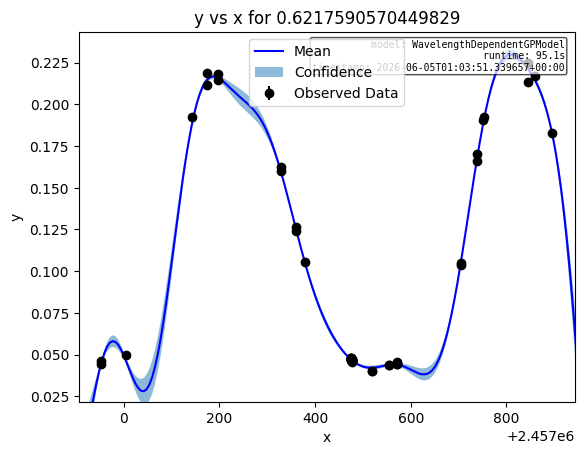

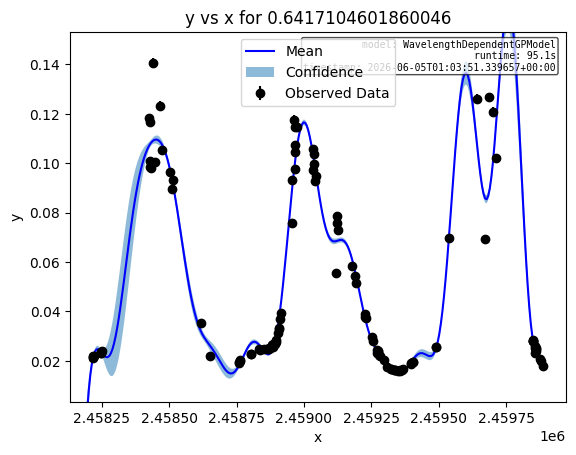

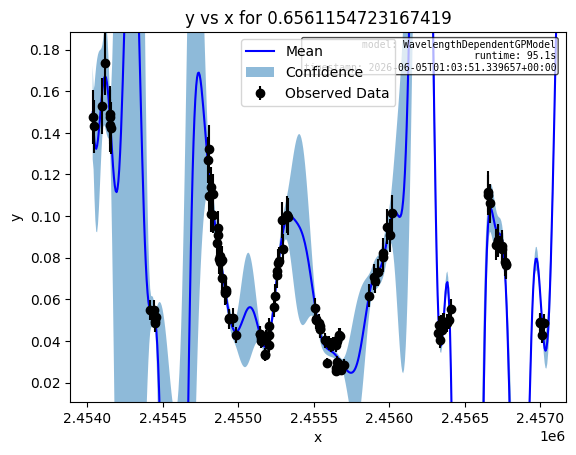

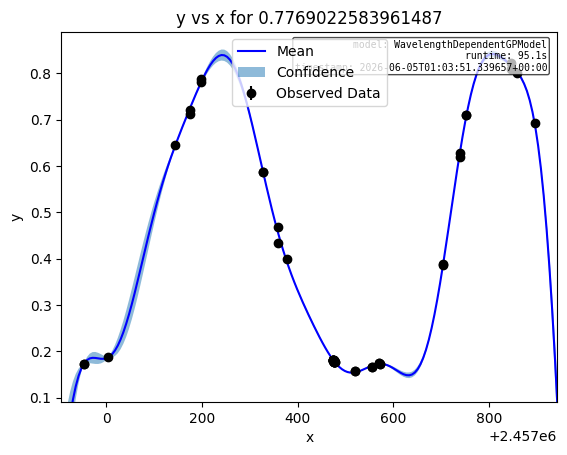

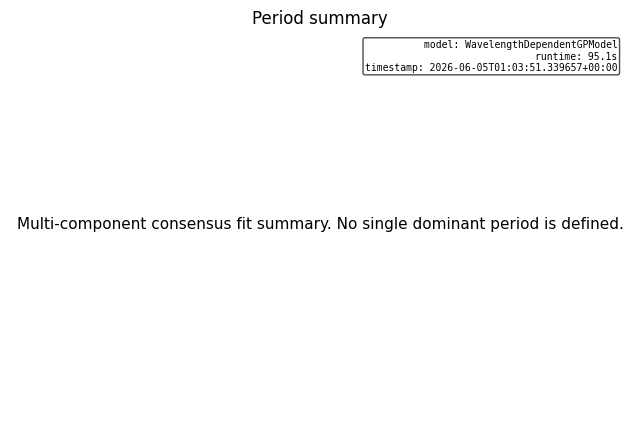

PERIOD SUMMARY
  Model name          : WavelengthDependentGPModel
  Method              : consensus_multicomp_period_summary
  Backend             : consensus_multicomp
  Kernel family       : ProductKernel
  Time-kernel family  : SpectralMixtureKernel
  Stochastic bg       : False
  Interval definition : none
  Dominant period     : N/A
  Dominant frequency  : N/A
  Peaks detected      : 0
  Peaks analyzed      : 0
  Peaks requested     : N/A
  Notes               : Multi-component consensus fit summary. No single dominant period is defined.

MULTI-COMPONENT PERIOD SUMMARY
  Component 0
      Consensus period: 596.386
      Fitted period: 640.633
      Initialized period: 596.386
      Period width: 29.8193
      Supported by: ASAS_SN/Misc_APASS.V, KELT/OSN_Johnson.Cousins_R3_0, KELT/OSN_Johnson.Cousins_R3_1, ZTF/Palomar_ZTF.g, ZTF/Palomar_ZTF.r
      Strength: 3.56993
      Consensus frequency: 0.00167677
      Drift from initialization: +7.42%
      Identity preserved: yes

  Compon

In [3]:
lc_2d = Lightcurve.from_csv(
    "10131+3049.csv",
    max_samples_per_band=120,
    max_samples=1000,
    check_sampling=True,
)

lc_2d.double()
num_components = 2
min_period = 50
max_period = 3000
vt_subsample = 0.001
training_iter = 500
lr = 0.02
miniter = 100
stop = 1e-3
stopavg = 10
max_components_per_band = 3
min_bands_per_component = 2
cluster_frequency_rtol = 0.10
constrain_consensus = True
wavelength_scaling = "linear"

fit_result = lc_2d.fit(
    model = "2DWavelengthDependent",
    time_kernel_type="spectral_mixture",
    wavelength_kernel_type="rbf",
    fit_strategy="consensus_multicomp",
    num_mixtures=num_components,
    max_components_per_band=max_components_per_band,
    min_bands_per_component=min_bands_per_component,
    cluster_frequency_rtol=cluster_frequency_rtol,
    constrain_consensus=True,
    training_iter=training_iter,
    lr=lr,
    miniter=miniter,
    stop=stop,
    stopavg=stopavg,
    verbose=True,
)

lc_2d.plot(
    annotate_provenance=True,
    provenance_location="upper right",
)

lc_2d.plot_period_summary(
    annotate_provenance=True,
    provenance_location="upper right",
    log_y=False, log_freq=False
)

period_summary = lc_2d.get_period_summary()
print(period_summary.to_text(max_peaks_to_show=2))

print(lc_2d.fit_history_to_text())
print(lc_2d.print_fit_history_summary(print_summary=False))

report = lc_2d.generate_reproducibility_report(
    latest_only=False,
    include_history=True,
    include_configurations=True,
    include_environment=True,
)
print(report)

## Interpretation of the Automatic Multi-Component Fit

The multi-component consensus workflow extends the single-component approach by allowing the consensus analysis to identify multiple recurring frequency clusters across the accepted bands. Rather than forcing all variability to be represented by a single spectral-mixture component, the Gaussian Process is given sufficient flexibility to model several consensus-supported timescales simultaneously.

An immediate consequence of this design is visible in the period-summary panel. Unlike the single-component case, the figure reports that no single dominant period is defined. This is expected behaviour. Once multiple consensus-supported components are present, reducing the solution to a single representative period would discard information about the structure that the model is attempting to capture. The absence of a dominant-period summary should therefore not be interpreted as a failure of the fit.

Visually, the light-curve reconstructions generally follow the observations more closely than in the single-component case. In particular, some of the residual structure that remained in the baseline model is reduced, and several bands exhibit a closer correspondence between the predicted and observed variability patterns. This improvement is the primary motivation for introducing additional spectral-mixture components.

However, the increased flexibility also introduces a potential warning sign. The fitted curves exhibit small-scale oscillatory structure that was largely absent in the single-component solution. These wiggles are particularly noticeable in regions where the observational cadence is sparse or where the data do not strongly constrain the shape of the variability. Although the model is capable of reproducing the observations more accurately, part of this improvement may arise from fitting noise or survey-specific structure rather than genuine astrophysical variability.

This behaviour illustrates a recurring trade-off in Gaussian Process modelling. Increasing the number of spectral-mixture components generally improves the apparent fit quality, but it also increases the number of free parameters and therefore the risk of overfitting. The present fit demonstrates that additional components can produce a more flexible description of the data, but it does not by itself establish that multiple physical periods are required.

For this reason, the remainder of the notebook investigates whether the additional complexity is astrophysically meaningful or whether similar improvements can be obtained through more targeted modifications to the wavelength-dependent structure of the model.


## Manual Harmonic Initialization Experiment

The previous fit allowed the consensus framework to determine how multiple spectral-mixture components should be initialized. We now consider a different experiment in which the second component is specified manually rather than inferred from the consensus analysis.

The motivation for this test is purely illustrative. Many long-period variables exhibit non-sinusoidal light curves whose shapes can sometimes be approximated by a fundamental period together with harmonic structure. To explore this possibility, the primary component is initialized near the consensus period while the second component is deliberately initialized near half that period.

It is important to emphasize that this second component is not derived from an independent period detection. Instead, it is introduced explicitly by the user in order to examine how the Gaussian Process behaves when harmonic structure is made available during the optimization.

Consequently, this experiment should not be interpreted as evidence for a second astrophysical period. Rather, it provides a useful diagnostic for determining whether some of the residual structure seen in the previous fits can be represented by harmonic flexibility within the model.

The results are therefore best evaluated by examining changes in fit quality, residual structure, and model behaviour, rather than by treating the manually specified component as a newly discovered variability timescale.

NOTE: this example is for illustration purposes only. The second component is intentionally chosen to be the harmonic, so it does not convey extra information.

In [4]:
# ---------------------------------------------------------------------
# User configuration
# ---------------------------------------------------------------------

OUTPUT_DIR = Path("consensus_fit_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_NAME = "IRAS 10131+3049 (CIT 6)"

MODEL_NAME = "2DWavelengthDependent"

TRAINING_ITER = 500

# Two spectral-mixture components.
NUM_MIXTURES = 2

CONSTRAINT_SET = "LPV"
PRIOR_SET = "LPV"

MIN_PERIOD_DAYS = 20.0
MAX_PERIOD_DAYS = 4500.0

MIN_FREQUENCY = 1.0 / MAX_PERIOD_DAYS
MAX_FREQUENCY = 1.0 / MIN_PERIOD_DAYS

USE_GP_VALIDATION = False
MIN_CONSENSUS_INLIERS = 2

LR = 0.05
GRID_SIZE = 2000
CUDA = False

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ---------------------------------------------------------------------
# Manual two-component consensus initialization
# ---------------------------------------------------------------------
# Component 1: main pulsation.
# Component 2: first harmonic. Adjust this if you want an LSP or another
# physically motivated secondary component instead.
PRIMARY_PERIOD_DAYS = 600.0
SECONDARY_PERIOD_DAYS = PRIMARY_PERIOD_DAYS / 2.0

CONSENSUS_PERIODS_DAYS = np.array(
    [PRIMARY_PERIOD_DAYS, SECONDARY_PERIOD_DAYS],
    dtype=float,
)

CONSENSUS_FREQUENCIES = 1.0 / CONSENSUS_PERIODS_DAYS

# Use fractional widths around each supplied frequency.
# These must be positive and finite.
CONSENSUS_FREQUENCY_WIDTHS = 0.03 * CONSENSUS_FREQUENCIES

print("Manual two-component consensus:")
for i, (p, f, w) in enumerate(
    zip(CONSENSUS_PERIODS_DAYS, CONSENSUS_FREQUENCIES, CONSENSUS_FREQUENCY_WIDTHS),
    start=1,
):
    print(f"  component {i}: period={p:.3f} d, frequency={f:.6g}, width={w:.6g}")

Manual two-component consensus:
  component 1: period=600.000 d, frequency=0.00166667, width=5e-05
  component 2: period=300.000 d, frequency=0.00333333, width=0.0001


/usr/local/lib/python3.12/dist-packages/pgmuvi/preprocess/quality.py:286: UserWarning: median_cadence is zero (many duplicate timestamps present). Falling back to the mean of positive gaps only for nyquist_period, nyquist_frequency, and duty_cycle; results may not be robust.
  metrics = compute_sampling_metrics(t, y, yerr)
/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:1417: UserWarning: Skipping band λ=0.4849115014076233 due to poor temporal sampling: Too few points: 12 < 15, Large gap: 702.00 (94.9% of baseline) > 30% threshold, Lightcurve contains large numbers of points with identical timestamps. Determining sampling quality using mean cadence instead of median; result may not be robust.
  return cls(xdata=x, ydata=y, yerr=yerr, **kwargs)
/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:1417: UserWarning: Skipping band λ=0.6201199889183044 due to poor temporal sampling: Large gap: 698.00 (47.7% of baseline) > 30% threshold
  return cls(xdata=x, ydata=y, ye

[Consensus] Deduplicated 2 -> 2 candidates


100%|██████████| 500/500 [01:17<00:00,  6.42it/s]
/usr/local/lib/python3.12/dist-packages/gpytorch/likelihoods/gaussian_likelihood.py:350: GPInputWarning: You have passed data through a FixedNoiseGaussianLikelihood that did not match the size of the fixed noise, *and* you did not specify noise. This is treated as a no-op.
  warnings.warn(


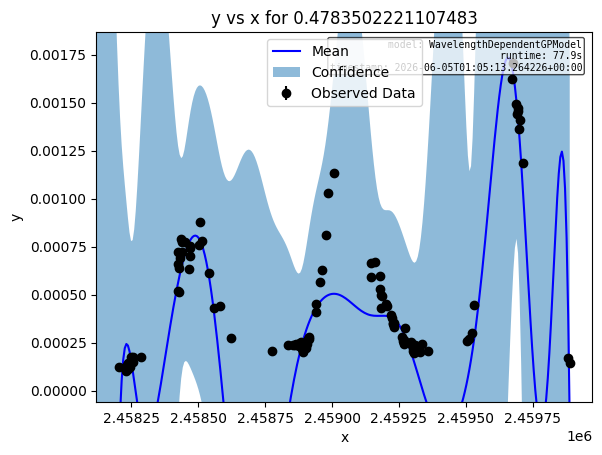

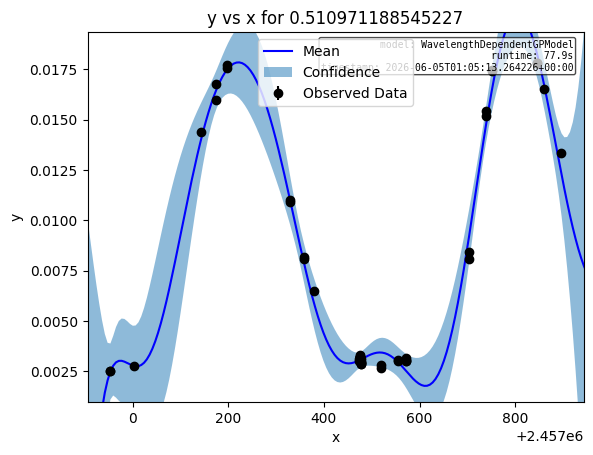

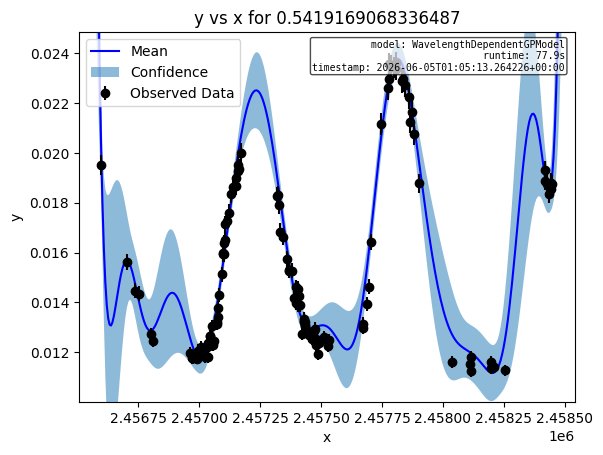

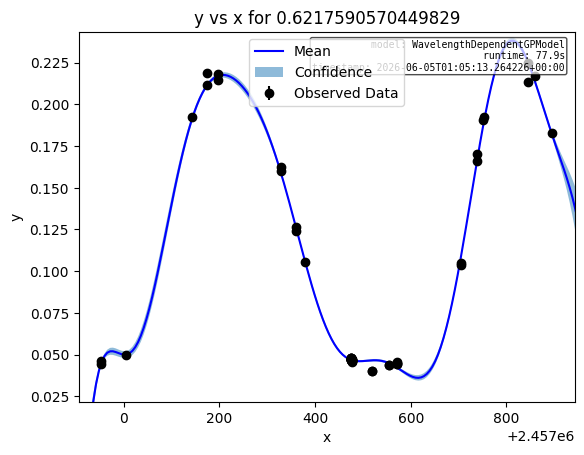

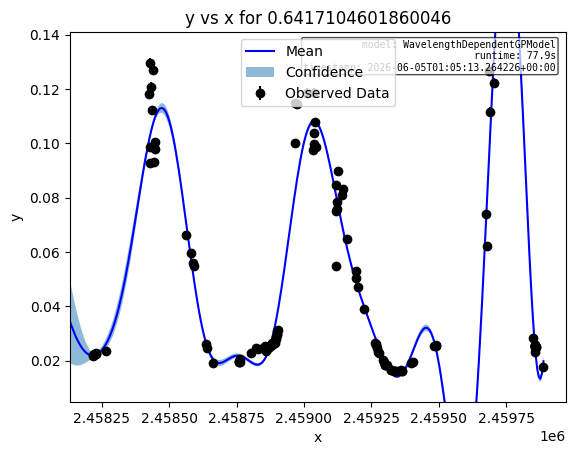

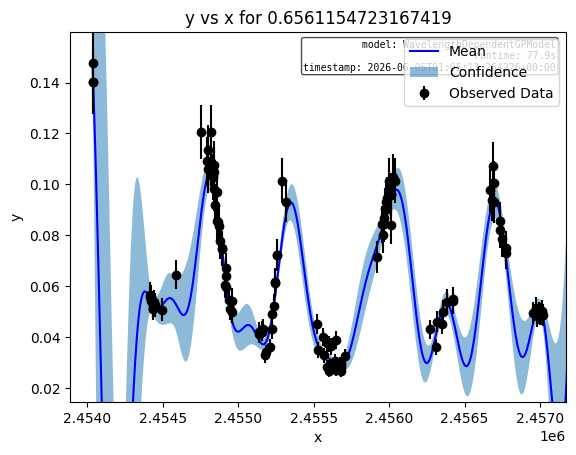

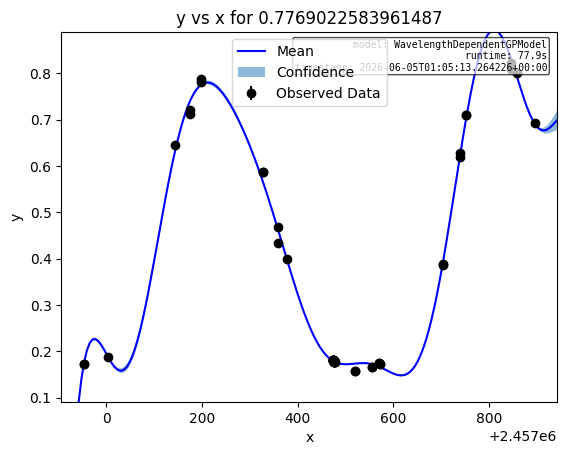

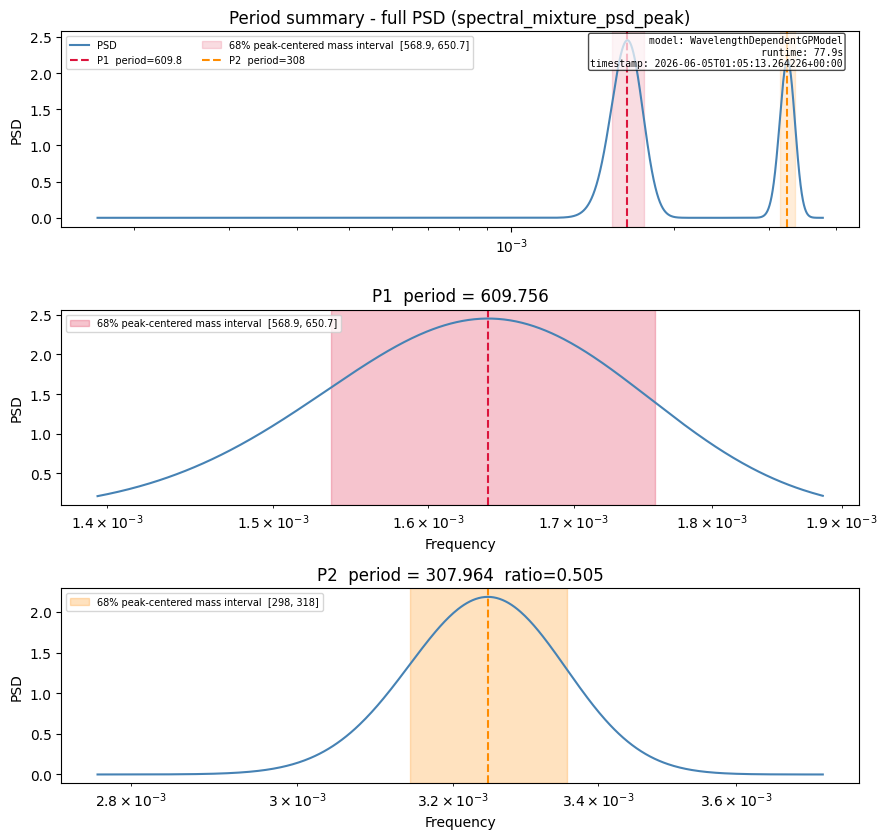

PERIOD SUMMARY
  Model name          : N/A
  Method              : spectral_mixture_psd_peak
  Backend             : separable_2d
  Kernel family       : ProductKernel
  Time-kernel family  : SpectralMixtureKernel
  Stochastic bg       : False
  Interval definition : peak_centered_68pct_mass_interval
  Dominant period     : 609.756
  Dominant frequency  : 0.00164
  Peaks detected      : 2
  Peaks analyzed      : 2
  Peaks requested     : N/A
  Notes               : Separable 2D model (separable_2d backend): period summary derived from the time kernel (SpectralMixtureKernel) only.  The wavelength kernel does not contribute to this period determination.  Spectral-mixture model (spectral_mixture backend).  Periods are derived from peaks of the SUMMED PSD on a frequency grid — this is the literature-comparable output.  The component periods/frequencies listed in the kernel component diagnostics section are direct kernel hyperparameter values and are for diagnostic purposes only; they are N

In [5]:
lc_2d = Lightcurve.from_csv(
    "10131+3049.csv",
    max_samples_per_band=120,
    max_samples=1000,
    check_sampling=True,
)

lc_2d.double()

# Temporary workaround for the current manual-consensus diagnostics bug:
# manual consensus_frequencies bypass automatic per-band accepted-band bookkeeping.
lc_2d._consensus_validate_result_structure = lambda *args, **kwargs: None

fit_result = lc_2d.fit(
    model="2DWavelengthDependent",
    time_kernel_type="spectral_mixture",
    wavelength_kernel_type="rbf",
    mean_module="quad",

    training_iter=TRAINING_ITER,
    num_mixtures=NUM_MIXTURES,
    constraint_set=CONSTRAINT_SET,
    cuda=CUDA,

    use_mls_init=False,
    use_best_band_init=False,

    fit_strategy="consensus",

    # Manual two-component consensus.
    consensus_frequencies=CONSENSUS_FREQUENCIES.tolist(),
    consensus_frequency_width=CONSENSUS_FREQUENCY_WIDTHS.tolist(),

    use_acf=True,
    use_gp_validation=False,
    min_consensus_inliers=1,
    outlier_sigma=2.0,
    consensus_dedup_rtol=0.02,

    constrain_consensus=True,
    consensus_width_factor=1.0,
    consensus_frequency_k=1.0,
    consensus_scale_max_factor=0.05,

    lr=0.05,
    stopavg=30,
    verbose=True,
)

lc_2d.plot(
    annotate_provenance=True,
    provenance_location="upper right",
)

lc_2d.plot_period_summary(
    annotate_provenance=True,
    provenance_location="upper right",
    log_y=False,
)

period_summary = lc_2d.get_period_summary()
print(period_summary.to_text(max_peaks_to_show=2))

print(lc_2d.fit_history_to_text())
print(lc_2d.print_fit_history_summary(print_summary=False))

report = lc_2d.generate_reproducibility_report(
    latest_only=False,
    include_history=True,
    include_configurations=True,
    include_environment=True,
)
print(report)

## Interpretation of the Manual Harmonic Experiment

Unlike the previous multi-component fit, the second spectral-mixture component in this experiment was not inferred from the data. Instead, it was intentionally initialized near half the primary period in order to investigate whether harmonic structure could account for some of the remaining discrepancies in the light-curve fits.

The resulting reconstructions generally appear smoother and more flexible than those obtained from the single-component model. In several bands the model is able to follow asymmetric maxima and minima more closely, and some residual structure is reduced. This behaviour is expected because the additional component provides the Gaussian Process with greater freedom to reproduce departures from a purely sinusoidal variability pattern.

At the same time, the overall character of the solution remains largely unchanged. The dominant variability timescale continues to be associated with the same long-period modulation identified by the consensus analysis. The manually introduced component primarily modifies the detailed shape of the fit rather than fundamentally changing the inferred variability timescale.

As in the automatic multi-component case, there are also indications that some of the additional flexibility may be excessive. Small-scale oscillatory structure appears in regions where the observational constraints are relatively weak, suggesting that part of the improvement in fit quality may reflect increased model flexibility rather than a genuine astrophysical signal. The presence of these wiggles serves as a reminder that a visually superior fit is not necessarily evidence for a more physically meaningful model.

The principal value of this experiment is therefore diagnostic rather than astrophysical. By introducing a known harmonic component, we can examine how sensitive the Gaussian Process is to additional periodic structure and assess whether the shortcomings of the baseline model are likely to arise from missing harmonics or from limitations in the wavelength-dependent description of the variability.

The results suggest that while harmonic flexibility can improve the detailed appearance of the fit, it does not fully resolve the behaviour of the shortest-wavelength band. This points toward wavelength-dependent effects as a more likely explanation for the remaining discrepancies and motivates the bespoke models explored in the following sections.


In [6]:
# ---------------------------------------------------------------------
# Restore baseline single-component configuration
# ---------------------------------------------------------------------

TRAINING_ITER = 500
NUM_MIXTURES = 1

MIN_CONSENSUS_INLIERS = 2
LR = 0.05

np.random.seed(RANDOM_SEED)

## Investigating the Shortest-Wavelength Discrepancy

The previous experiments explored whether additional spectral-mixture components could improve the fit. Although these models often produced visually better reconstructions, they did not fully resolve the behaviour of the shortest-wavelength band. Furthermore, increasing the number of components introduced a growing risk of overfitting and made the interpretation of the resulting models less straightforward.

At this stage, it is useful to shift focus from the temporal structure of the Gaussian Process to its wavelength dependence. The dominant period appears to be broadly consistent across the accepted bands, and the largest remaining discrepancy is concentrated at the blue edge of the wavelength range. This suggests that the principal limitation may not be the number of periodic components, but rather how the model couples information between wavelengths.

The following experiments therefore investigate the behaviour of the shortest-wavelength band directly. Rather than introducing additional periodic structure, we examine how changes to the wavelength-dependent component of the model affect the fit quality and uncertainty estimates.


Remove the shortest-wavelength band from the entire 2D fit, then run the `2DWavelengthDependent` consensus fit

/usr/local/lib/python3.12/dist-packages/pgmuvi/preprocess/quality.py:286: UserWarning: median_cadence is zero (many duplicate timestamps present). Falling back to the mean of positive gaps only for nyquist_period, nyquist_frequency, and duty_cycle; results may not be robust.
  metrics = compute_sampling_metrics(t, y, yerr)
/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:1417: UserWarning: Skipping band λ=0.4849115014076233 due to poor temporal sampling: Too few points: 12 < 15, Large gap: 702.00 (94.9% of baseline) > 30% threshold, Lightcurve contains large numbers of points with identical timestamps. Determining sampling quality using mean cadence instead of median; result may not be robust.
  return cls(xdata=x, ydata=y, yerr=yerr, **kwargs)
/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:1417: UserWarning: Skipping band λ=0.6201199889183044 due to poor temporal sampling: Large gap: 698.00 (47.7% of baseline) > 30% threshold
  return cls(xdata=x, ydata=y, ye

Dropping shortest-wavelength band from entire 2D fit:
  wavelength = 0.47835022
  band       = ZTF/Palomar_ZTF.g
[consensus] accepted bands: ['KELT/OSN_Johnson.Cousins_R3_0', 'ASAS_SN/Misc_APASS.V', 'ZTF/Palomar_ZTF.r']
[consensus] rejected bands: ['KELT/OSN_Johnson.Cousins_R3_1', 'GAIA_DR3/GAIA_GAIA3.Gbp', 'GAIA_DR3/GAIA_GAIA3.G', 'GAIA_DR3/GAIA_GAIA3.Grp']
[consensus] band=KELT/OSN_Johnson.Cousins_R3_0 dominant_period=609.592 dominant_frequency=0.00164044 acf_status=agreement harmonic_order=1
[consensus] band=KELT/OSN_Johnson.Cousins_R3_1 rejected: max_gap_fraction (0.294 > 0.25)
[consensus] band=ASAS_SN/Misc_APASS.V dominant_period=597.097 dominant_frequency=0.00167477 acf_status=agreement harmonic_order=1
[consensus] band=GAIA_DR3/GAIA_GAIA3.Gbp rejected: duty_cycle (0.0151 < 0.0793)
[consensus] band=GAIA_DR3/GAIA_GAIA3.G rejected: duty_cycle (0.0149 < 0.0793)
[consensus] band=GAIA_DR3/GAIA_GAIA3.Grp rejected: duty_cycle (0.0151 < 0.0793)
[consensus] band=ZTF/Palomar_ZTF.r dominant

100%|██████████| 500/500 [00:37<00:00, 13.41it/s]
/usr/local/lib/python3.12/dist-packages/gpytorch/likelihoods/gaussian_likelihood.py:350: GPInputWarning: You have passed data through a FixedNoiseGaussianLikelihood that did not match the size of the fixed noise, *and* you did not specify noise. This is treated as a no-op.
  warnings.warn(


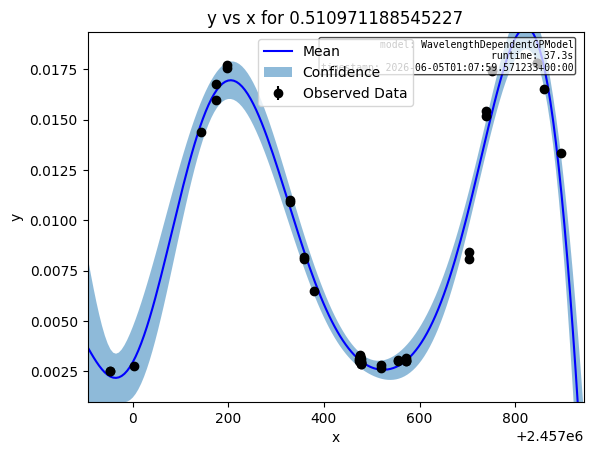

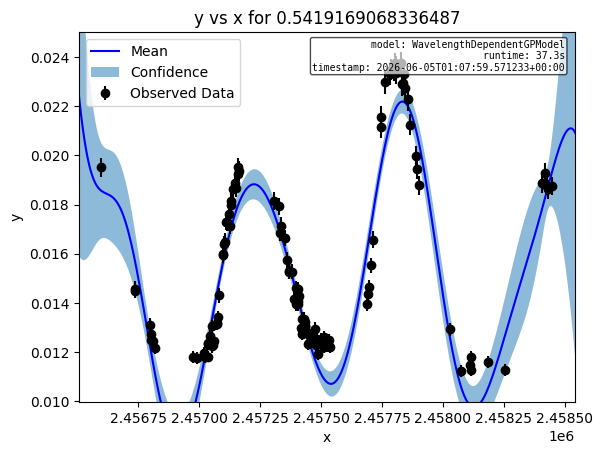

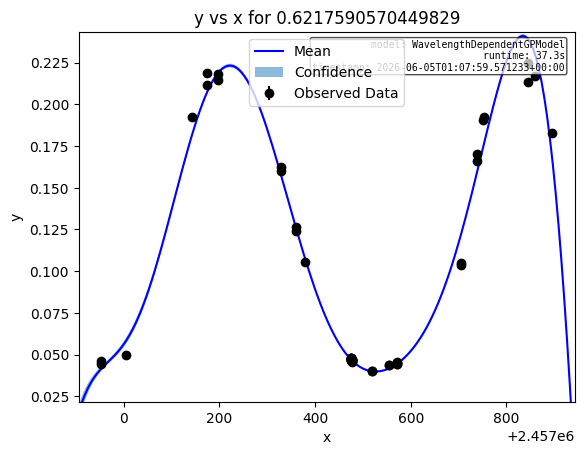

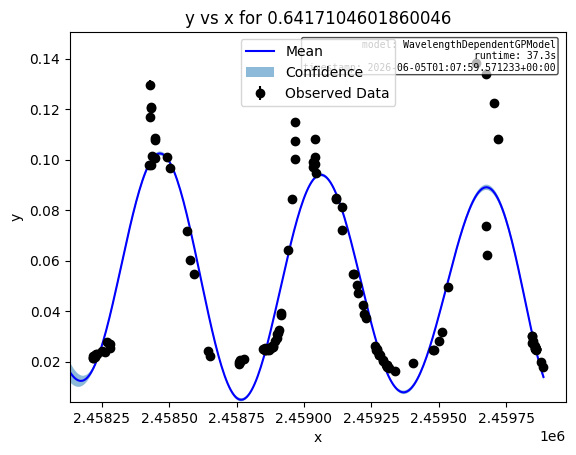

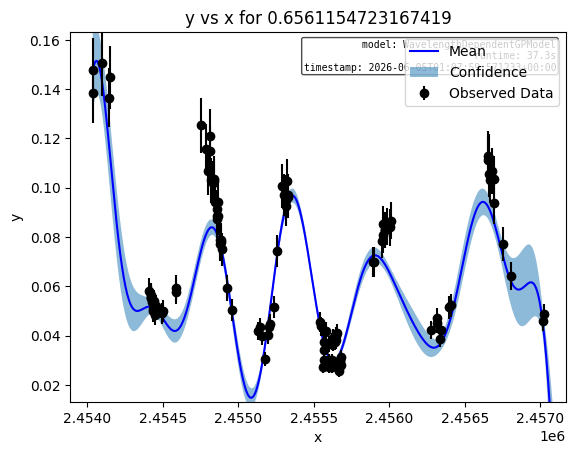

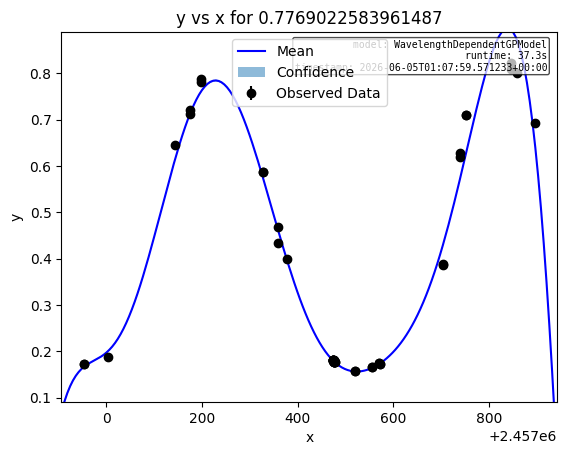

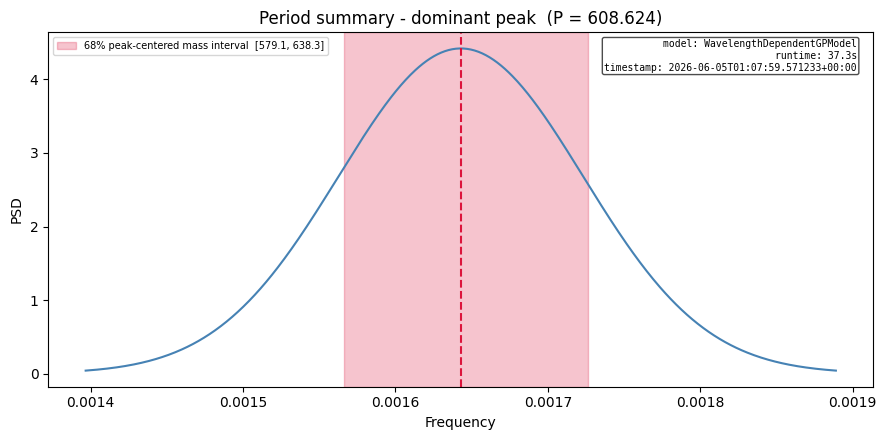

PERIOD SUMMARY
  Model name          : N/A
  Method              : spectral_mixture_psd_peak
  Backend             : separable_2d
  Kernel family       : ProductKernel
  Time-kernel family  : SpectralMixtureKernel
  Stochastic bg       : False
  Interval definition : peak_centered_68pct_mass_interval
  Dominant period     : 608.624
  Dominant frequency  : 0.00164305
  Peaks detected      : 1
  Peaks analyzed      : 1
  Peaks requested     : N/A
  Notes               : Separable 2D model (separable_2d backend): period summary derived from the time kernel (SpectralMixtureKernel) only.  The wavelength kernel does not contribute to this period determination.  Spectral-mixture model (spectral_mixture backend).  Periods are derived from peaks of the SUMMED PSD on a frequency grid — this is the literature-comparable output.  The component periods/frequencies listed in the kernel component diagnostics section are direct kernel hyperparameter values and are for diagnostic purposes only; they ar

In [7]:
lc_2d_full = Lightcurve.from_csv("10131+3049.csv", max_samples_per_band=120, max_samples=1000, check_sampling=True,)

# Identify the shortest-wavelength retained band from xdata column 1.
# Use the corresponding band label, then remove that band from the entire fit.
x_np = lc_2d_full._xdata_raw.detach().cpu().numpy()
band_np = lc_2d_full.band.astype(str)

shortest_wavelength = np.nanmin(x_np[:, 1])
shortest_band = band_np[np.nanargmin(x_np[:, 1])]

print("Dropping shortest-wavelength band from entire 2D fit:")
print("  wavelength =", shortest_wavelength)
print("  band       =", shortest_band)

lc_2d = lc_2d_full.drop_bands([shortest_band])
lc_2d.double()

fit_result = lc_2d.fit(
    # model="2D",
    model="2DWavelengthDependent",
    time_kernel_type="spectral_mixture",
    wavelength_kernel_type="rbf",
    mean_module="quad",
    training_iter=TRAINING_ITER,
    num_mixtures=NUM_MIXTURES,
    constraint_set=CONSTRAINT_SET,
    cuda=CUDA,
    use_mls_init=False,
    use_best_band_init=False,
    fit_strategy="consensus",
    use_acf=True,
    use_gp_validation=False,
    min_consensus_inliers=2,
    outlier_sigma=2.0,
    consensus_dedup_rtol=0.02,
    constrain_consensus=True,
    consensus_width_factor=1.0,
    consensus_frequency_k=1.0,
    consensus_scale_max_factor=0.05,
    lr=0.05,
    stopavg=30,
    verbose=True,
)

lc_2d.plot(annotate_provenance=True, provenance_location="upper right")
lc_2d.plot_period_summary(annotate_provenance=True, provenance_location="upper right",
                          log_y=False, log_freq=False)

period_summary = lc_2d.get_period_summary()
print(period_summary.to_text(max_peaks_to_show=2))
print(lc_2d.fit_history_to_text())
print(lc_2d.print_fit_history_summary(print_summary=False))

report = lc_2d.generate_reproducibility_report(
    latest_only=False,
    include_history=True,
    include_configurations=True,
    include_environment=True,
)
print(report)

## Interpretation of Removing the Shortest-Wavelength Band

The shortest-wavelength band was identified as the most problematic component of the baseline fit. A natural question is whether this band is merely difficult to model in isolation, or whether it is actively influencing the behaviour of the consensus-constrained Gaussian Process.

To investigate this possibility, the shortest-wavelength band was removed entirely and the consensus analysis and Gaussian Process fit were repeated using only the remaining wavelengths.

The resulting fit shows that the overall behaviour of the model remains largely unchanged. The dominant variability timescale remains close to the value inferred previously, and the remaining wavelength bands continue to be fit reasonably well. No dramatic improvement is observed in the quality of the reconstructions for the other bands.

This result suggests that the shortest-wavelength band is not driving the global solution. Instead, the discrepancy appears to be localized to that particular wavelength. In other words, the consensus period inferred from the remaining bands is already stable, and removing the blue-edge light curve does not reveal a fundamentally different variability pattern.

From the perspective of model development, this is an important diagnostic result. It indicates that the primary challenge is not determining the correct period, but rather describing how the variability properties evolve toward the shortest wavelengths. This observation motivates the subsequent investigation of wavelength-dependent model modifications rather than further changes to the consensus period determination itself.


## Bespoke Wavelength-Local Residual Model

The previous experiments suggest that the main limitation of the baseline model is not the recovery of the dominant period. The consensus period remains stable near the same long-timescale variability even when the shortest-wavelength band is removed from the fit. The difficulty is instead concentrated in how the model describes the wavelength dependence of the variability, especially at the blue edge of the available wavelength range.

The standard `2DWavelengthDependent` model uses a shared periodic time kernel coupled smoothly across wavelength. This is appropriate when the same variability pattern changes gradually from band to band. However, the shortest-wavelength light curve shows systematic deviations that are not fully captured by this smooth shared component.

To test whether additional wavelength-local flexibility can improve the fit, we define a bespoke additive Gaussian Process model. The covariance is written as the sum of two terms:

`K = K_SM_time × K_smooth_wavelength + K_residual_time × K_local_wavelength`

The first term is the shared scientific component. It carries the periodic signal and remains responsible for the period interpretation. The second term is a local residual component. Its purpose is not to introduce a new physical period, but to provide controlled band-local flexibility where the shared wavelength-dependent component is insufficient.

This separation is important. By keeping the spectral-mixture time kernel in the shared component and assigning `sci_kernel` to that component, the period-summary machinery continues to interpret the dominant period using the same periodic kernel as before. The residual term is treated as a modelling correction rather than as an additional period-bearing component.


In [9]:
import torch
import gpytorch
from gpytorch.constraints import Interval

from gpytorch.models import ExactGP
from gpytorch.distributions import MultivariateNormal as MVN
from gpytorch.kernels import (
    SpectralMixtureKernel,
    RBFKernel,
    MaternKernel,
    ScaleKernel,
)
from pgmuvi.gps import (
    CustomQuadConstantMean,
    CustomLinearConstantMean,
    DustMean,
    PowerLawMean,
)


class WavelengthDependentLocalResidualGPModel(ExactGP):
    """
    Notebook prototype.

    Covariance:
        K = K_SM_time * K_smooth_wavelength
          + K_residual_time * K_local_wavelength

    The shared SM time kernel carries the period. The local residual term gives
    wavelength-local flexibility, especially for bands that are not well
    described as a smooth continuation of neighboring wavelengths.
    """

    def __init__(
        self,
        train_x,
        train_y,
        likelihood,
        num_mixtures=1,
        mean_module="quad",
        wavelength_kernel_type="rbf",
        smooth_wavelength_lengthscale=None,
        local_wavelength_lengthscale=None,
        residual_time_lengthscale=None,
        residual_outputscale=0.05,
    ):
        super().__init__(train_x, train_y, likelihood)

        dtype = train_x.dtype
        device = train_x.device

        if mean_module is None or mean_module in ("quad", "quadratic", "quad_constant"):
            self.mean_module = CustomQuadConstantMean()
        elif mean_module in ("linear", "linear_mean"):
            self.mean_module = CustomLinearConstantMean()
        elif mean_module in ("constant", "constant_mean"):
            self.mean_module = gpytorch.means.ConstantMean()
        elif mean_module in ("dust", "dust_mean"):
            self.mean_module = DustMean()
        elif mean_module in ("power_law", "power_law_mean"):
            self.mean_module = PowerLawMean()
        elif isinstance(mean_module, gpytorch.means.Mean):
            self.mean_module = mean_module
        else:
            raise ValueError(f"Unsupported mean_module={mean_module!r}")

        self.mean_module = self.mean_module.to(dtype=dtype, device=device)

        time_span = float(train_x[:, 0].max() - train_x[:, 0].min())
        wl_span = float(train_x[:, 1].max() - train_x[:, 1].min())

        if smooth_wavelength_lengthscale is None:
            smooth_wavelength_lengthscale = max(wl_span / 2.0, 1.0e-3)

        if local_wavelength_lengthscale is None:
            local_wavelength_lengthscale = max(wl_span / 20.0, 1.0e-4)

        if residual_time_lengthscale is None:
            residual_time_lengthscale = max(time_span / 8.0, 1.0)

        shared_time_kernel = SpectralMixtureKernel(
            num_mixtures=num_mixtures,
            ard_num_dims=1,
            active_dims=[0],
        )

        if wavelength_kernel_type == "rbf":
            smooth_wavelength_kernel = ScaleKernel(
                RBFKernel(active_dims=[1])
            )
        elif wavelength_kernel_type == "matern":
            smooth_wavelength_kernel = ScaleKernel(
                MaternKernel(nu=1.5, active_dims=[1])
            )
        else:
            raise ValueError("wavelength_kernel_type must be 'rbf' or 'matern'")

        smooth_wavelength_kernel.base_kernel.lengthscale = torch.as_tensor(
            smooth_wavelength_lengthscale,
            dtype=dtype,
            device=device,
        )

        smooth_wavelength_kernel.base_kernel.register_constraint(
            "raw_lengthscale", Interval(0.75 * wl_span, 10.0 * wl_span),
            )

        shared_component = shared_time_kernel * smooth_wavelength_kernel

        residual_time_kernel = ScaleKernel(
            MaternKernel(nu=1.5, active_dims=[0])
        )
        residual_time_kernel.base_kernel.lengthscale = torch.as_tensor(
            residual_time_lengthscale,
            dtype=dtype,
            device=device,
        )
        residual_time_kernel.outputscale = torch.as_tensor(
            residual_outputscale,
            dtype=dtype,
            device=device,
        )

        local_wavelength_kernel = ScaleKernel(
            MaternKernel(nu=1.5, active_dims=[1])
        )
        local_wavelength_kernel.base_kernel.lengthscale = torch.as_tensor(
            local_wavelength_lengthscale,
            dtype=dtype,
            device=device,
        )
        local_wavelength_kernel.outputscale = torch.as_tensor(
            residual_outputscale,
            dtype=dtype,
            device=device,
        )

        local_component = residual_time_kernel * local_wavelength_kernel

        self.shared_component = shared_component
        self.local_component = local_component
        self.covar_module = shared_component + local_component

        # Important: keep period-summary and consensus period interpretation
        # attached to the shared periodic separable component, not to the
        # additive residual component.
        self.sci_kernel = shared_component

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return MVN(mean_x, covar_x)

## Constraining the Bespoke Model

The bespoke model introduces additional flexibility through a wavelength-local residual component. This flexibility is useful, but it also creates a risk: the residual term can become a second unconstrained Gaussian Process that absorbs structure the shared periodic component should be modelling, or it can introduce artificial wiggles in sparsely constrained regions of the light curve.

For this reason, the following cell applies explicit constraints to the residual component. The residual time kernel is constrained to remain relatively smooth, preventing it from fitting rapid fluctuations. The residual wavelength kernel is constrained so that it remains local enough to correct band-specific behaviour, but not so local that the shortest-wavelength band becomes effectively independent of the rest of the model.

In addition, the shared wavelength kernel is given a slightly stronger coherence constraint than the default. The lower bound on its wavelength lengthscale is raised from `0.75 × wl_span` to `1.0 × wl_span`. This choice was found to be a useful compromise: it reduces blue-edge amplitude inflation without forcing the pathological behaviour seen when the lower bound is increased too aggressively, for example to `2.0 × wl_span`.

The goal is therefore not to make the model arbitrarily flexible, but to allow controlled wavelength-local corrections while preserving the consensus-constrained shared periodic interpretation.

In [10]:
lc_2d = Lightcurve.from_csv("10131+3049.csv", max_samples_per_band=150, max_samples=1000, check_sampling=True,)

lc_2d.double()

# Build a likelihood explicitly so the custom model and Lightcurve use the same one.
lc_2d.set_likelihood(None, variance=False)
local_residual_likelihood = lc_2d.likelihood

# local_residual_model = WavelengthDependentLocalResidualGPModel(
#     lc_2d._xdata_transformed,
#     lc_2d._ydata_transformed,
#     local_residual_likelihood,
#     num_mixtures=NUM_MIXTURES,
#     mean_module="quad",
#     wavelength_kernel_type="rbf",

#     # Tune these first.
#     local_wavelength_lengthscale=None,
#     residual_time_lengthscale=None,
#     residual_outputscale=0.02,
# )
from gpytorch.constraints import Interval

local_residual_model = WavelengthDependentLocalResidualGPModel(
    lc_2d._xdata_transformed,
    lc_2d._ydata_transformed,
    local_residual_likelihood,
    num_mixtures=NUM_MIXTURES,
    mean_module="quad",
    wavelength_kernel_type="rbf",

    # Make the residual less local in wavelength.
    local_wavelength_lengthscale=0.08,

    # Make the residual smoother in time.
    residual_time_lengthscale=300.0,

    # Initial value only; constraints below prevent optimizer blow-up.
    residual_outputscale=0.00000005,
)

# Constrain the local residual component so it remains a weak correction,
# not a second free GP that can inflate variance at edge wavelengths.
local_residual_model.local_component.kernels[0].register_constraint(
    "raw_outputscale",
    Interval(1.0e-8, 2.0e-3),
)

local_residual_model.local_component.kernels[1].register_constraint(
    "raw_outputscale",
    Interval(1.0e-8, 7.0e-3),
)

# Prevent rapid temporal wiggles in the residual component.
local_residual_model.local_component.kernels[0].base_kernel.register_constraint(
    "raw_lengthscale",
    Interval(75.0, 1000.0),
)

# Prevent the wavelength-local residual from becoming effectively independent
# in the shortest-wavelength edge band.
local_residual_model.local_component.kernels[1].base_kernel.register_constraint(
    "raw_lengthscale",
    Interval(0.03, 0.20),
)

# Enforce stronger wavelength coherence in the shared periodic component.
# This reduces edge-band amplitude inflation by preventing the shared
# wavelength kernel from becoming excessively local in wavelength.
# 1.0 enforces moderate wavelength coherence in the shared periodic component
#    without forcing the model into the pathological behavior seen for 2.0 * wl_span
print("Default bounds on shared periodic component:",
    local_residual_model.shared_component.kernels[1].base_kernel.raw_lengthscale_constraint
)

wl_span = float(
    lc_2d._xdata_transformed[:, 1].max()
    - lc_2d._xdata_transformed[:, 1].min()
)

local_residual_model.shared_component.kernels[1].base_kernel.register_constraint(
    "raw_lengthscale",
    Interval(1.0 * wl_span, 10.0 * wl_span),
)

print("Modified bounds on shared periodic component:",
    local_residual_model.shared_component.kernels[1].base_kernel.raw_lengthscale_constraint
)

Default bounds on shared periodic component: Interval(2.239E-01, 2.986E+00)
Modified bounds on shared periodic component: Interval(2.986E-01, 2.986E+00)


/usr/local/lib/python3.12/dist-packages/pgmuvi/preprocess/quality.py:286: UserWarning: median_cadence is zero (many duplicate timestamps present). Falling back to the mean of positive gaps only for nyquist_period, nyquist_frequency, and duty_cycle; results may not be robust.
  metrics = compute_sampling_metrics(t, y, yerr)
/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:1417: UserWarning: Skipping band λ=0.4849115014076233 due to poor temporal sampling: Too few points: 12 < 15, Large gap: 702.00 (94.9% of baseline) > 30% threshold, Lightcurve contains large numbers of points with identical timestamps. Determining sampling quality using mean cadence instead of median; result may not be robust.
  return cls(xdata=x, ydata=y, yerr=yerr, **kwargs)
/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:1417: UserWarning: Skipping band λ=0.6201199889183044 due to poor temporal sampling: Large gap: 698.00 (47.7% of baseline) > 30% threshold
  return cls(xdata=x, ydata=y, ye

[consensus] accepted bands: ['KELT/OSN_Johnson.Cousins_R3_1', 'ASAS_SN/Misc_APASS.V', 'ZTF/Palomar_ZTF.g', 'ZTF/Palomar_ZTF.r']
[consensus] rejected bands: ['KELT/OSN_Johnson.Cousins_R3_0', 'GAIA_DR3/GAIA_GAIA3.Gbp', 'GAIA_DR3/GAIA_GAIA3.G', 'GAIA_DR3/GAIA_GAIA3.Grp']
[consensus] band=KELT/OSN_Johnson.Cousins_R3_0 rejected: ls_acf_disagreement
[consensus] band=KELT/OSN_Johnson.Cousins_R3_1 dominant_period=617.447 dominant_frequency=0.00161957 acf_status=harmonic harmonic_order=2
[consensus] band=ASAS_SN/Misc_APASS.V dominant_period=597.097 dominant_frequency=0.00167477 acf_status=agreement harmonic_order=1
[consensus] band=GAIA_DR3/GAIA_GAIA3.Gbp rejected: duty_cycle (0.0151 < 0.122)
[consensus] band=GAIA_DR3/GAIA_GAIA3.G rejected: duty_cycle (0.0149 < 0.122)
[consensus] band=GAIA_DR3/GAIA_GAIA3.Grp rejected: duty_cycle (0.0151 < 0.122)
[consensus] band=ZTF/Palomar_ZTF.g dominant_period=624.537 dominant_frequency=0.00160119 acf_status=agreement harmonic_order=1
[consensus] band=ZTF/Pal

100%|██████████| 1000/1000 [03:50<00:00,  4.33it/s]
/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:4397: UserWarning: fit_configuration snapshot contains an unsupported object placeholder at fit_configuration.user_kwargs.likelihood (gpytorch.likelihoods.gaussian_likelihood.callable).
  _warn(
/usr/local/lib/python3.12/dist-packages/gpytorch/likelihoods/gaussian_likelihood.py:350: GPInputWarning: You have passed data through a FixedNoiseGaussianLikelihood that did not match the size of the fixed noise, *and* you did not specify noise. This is treated as a no-op.
  warnings.warn(


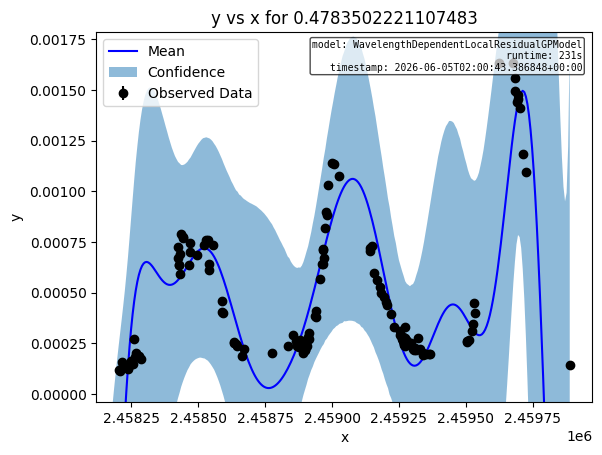

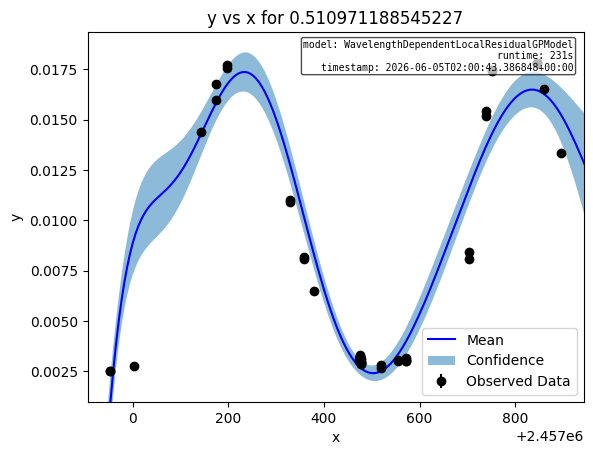

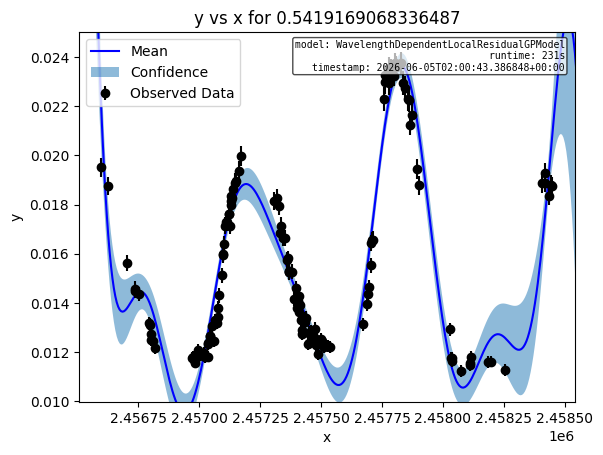

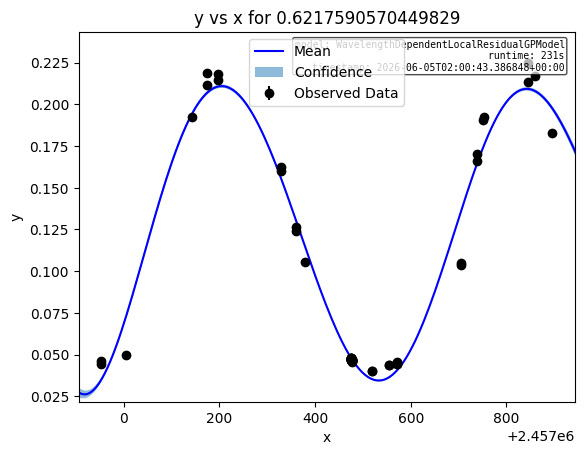

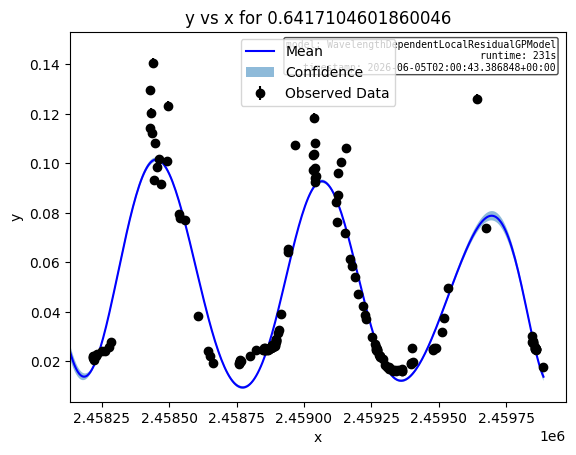

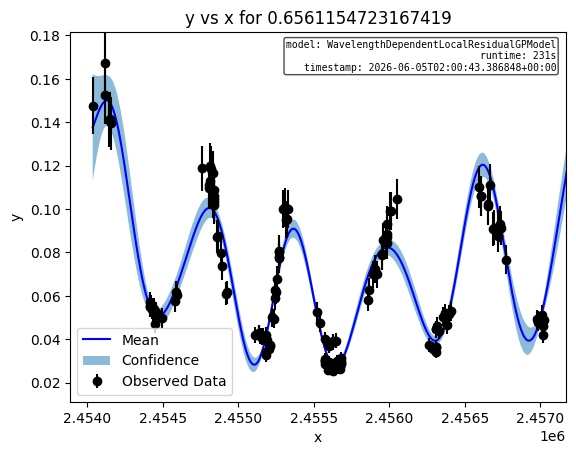

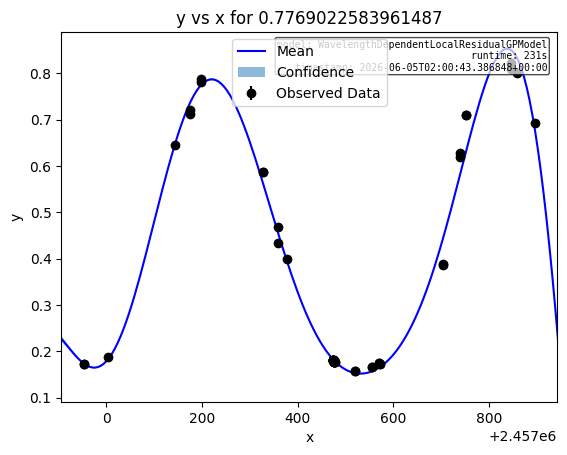

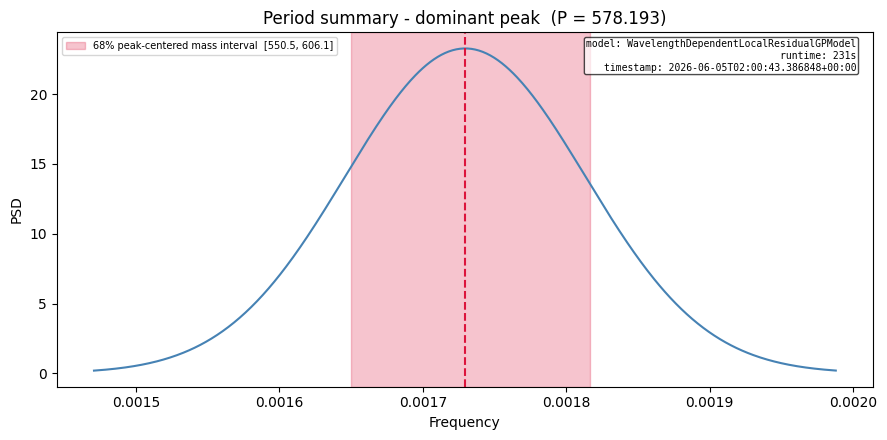

PERIOD SUMMARY
  Model name          : N/A
  Method              : spectral_mixture_psd_peak
  Backend             : separable_2d
  Kernel family       : ProductKernel
  Time-kernel family  : SpectralMixtureKernel
  Stochastic bg       : False
  Interval definition : peak_centered_68pct_mass_interval
  Dominant period     : 578.193
  Dominant frequency  : 0.00172953
  Peaks detected      : 1
  Peaks analyzed      : 1
  Peaks requested     : N/A
  Notes               : Separable 2D model (separable_2d backend): period summary derived from the time kernel (SpectralMixtureKernel) only.  The wavelength kernel does not contribute to this period determination.  Spectral-mixture model (spectral_mixture backend).  Periods are derived from peaks of the SUMMED PSD on a frequency grid — this is the literature-comparable output.  The component periods/frequencies listed in the kernel component diagnostics section are direct kernel hyperparameter values and are for diagnostic purposes only; they ar

In [14]:
fit_result = lc_2d.fit(
    model=local_residual_model,
    likelihood=local_residual_likelihood,

    training_iter=1000,
    num_mixtures=1,
    constraint_set=CONSTRAINT_SET,
    cuda=CUDA,
    use_mls_init=False,
    use_best_band_init=False,
    fit_strategy="consensus",
    use_acf=True,
    use_gp_validation=False,
    min_consensus_inliers=3,
    outlier_sigma=2.0,
    consensus_dedup_rtol=0.02,
    constrain_consensus=True,
    consensus_width_factor=1.0,
    consensus_frequency_k=1.0,
    consensus_scale_max_factor=0.05,
    lr=0.05,
    stopavg=30,
    verbose=True,
)


lc_2d.plot(annotate_provenance=True, provenance_location="upper right")
lc_2d.plot_period_summary(annotate_provenance=True, provenance_location="upper right",
                          log_y=False, log_freq=False)

period_summary = lc_2d.get_period_summary()
print(period_summary.to_text(max_peaks_to_show=2))
print(lc_2d.fit_history_to_text())
print(lc_2d.print_fit_history_summary(print_summary=False))

report = lc_2d.generate_reproducibility_report(
    latest_only=False,
    include_history=True,
    include_configurations=True,
    include_environment=True,
)
print(report)

## Interpretation of the Bespoke Model

The bespoke model was introduced to address the principal shortcoming of the baseline wavelength-dependent fit: the poor reconstruction of the shortest-wavelength light curve. By separating the covariance into a shared periodic component and a wavelength-local residual component, the model is able to represent behaviour that cannot be described as a smooth continuation of the variability seen at neighbouring wavelengths.

The resulting fit generally improves the agreement between the model and the observations, particularly at the blue edge of the wavelength range. The shortest-wavelength band is reproduced more accurately than in the baseline model, and the mean variability level is brought into better agreement with the data.

At the same time, the increased flexibility reveals a new issue. The fitted curves exhibit small-scale oscillatory structure that is not obviously supported by the observations. These wiggles are most apparent in regions where the data provide relatively weak constraints and are a classic indication that the model is beginning to use its additional degrees of freedom to fit structure that may not be astrophysical.

Subsequent diagnostics show that the excess variability at the shortest wavelength does not arise primarily from the residual component itself. Instead, the shared wavelength-dependent periodic component tends to assign too much amplitude to the blue edge of the wavelength range. The residual term then partially compensates for this behaviour. This finding suggests that the remaining challenge lies not in the temporal model, but in how the periodic variability is allowed to evolve with wavelength.

The remainder of this section therefore focuses on constraining the wavelength dependence of the shared component in order to retain the improved fit quality while reducing the tendency toward overfitting.


## Understanding the Blue-Edge Behaviour

Although the bespoke model improves the fit, it does not by itself explain *why* the shortest-wavelength band behaves differently from the rest of the dataset. The improved reconstruction could arise from a physically meaningful correction to the wavelength dependence of the variability, or it could simply reflect the additional flexibility introduced by the residual component.

To distinguish between these possibilities, we now examine a series of diagnostic plots that compare the model predictions and observations as a function of wavelength. These diagnostics allow us to determine whether the discrepancy originates from the shared periodic component, the local residual component, or their interaction.

The objective is not merely to obtain a visually acceptable fit, but to identify the specific part of the model responsible for the remaining shortcomings at the blue edge of the wavelength range. This information is essential for deciding whether further improvements should focus on the temporal structure of the Gaussian Process, the wavelength-dependent coupling, or the treatment of band-local residuals.

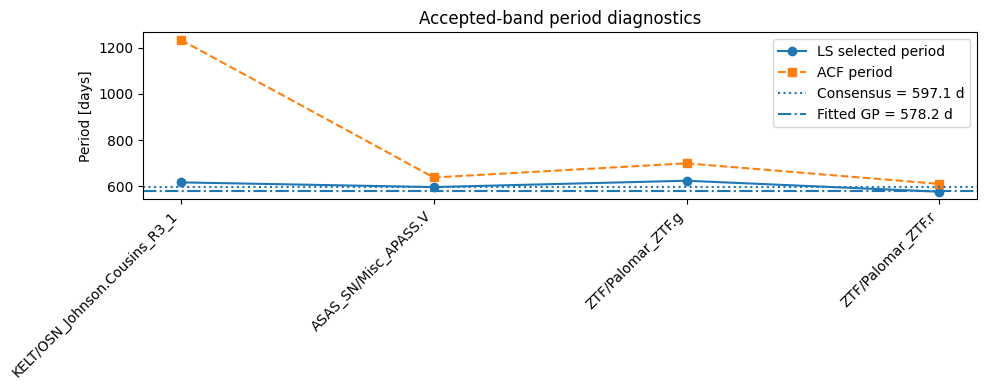

Consensus period: 597.0967741935483
Fitted GP period: 578.1576078950542
Fitted GP frequency: 0.0017296321735534744
Consensus bounds: [0.0016195727084769124, 0.0017299680802859189]
Scale bounds: [1e-06, 8.373851971907079e-05]
Fitted SM scale: 8.36964342460846e-05


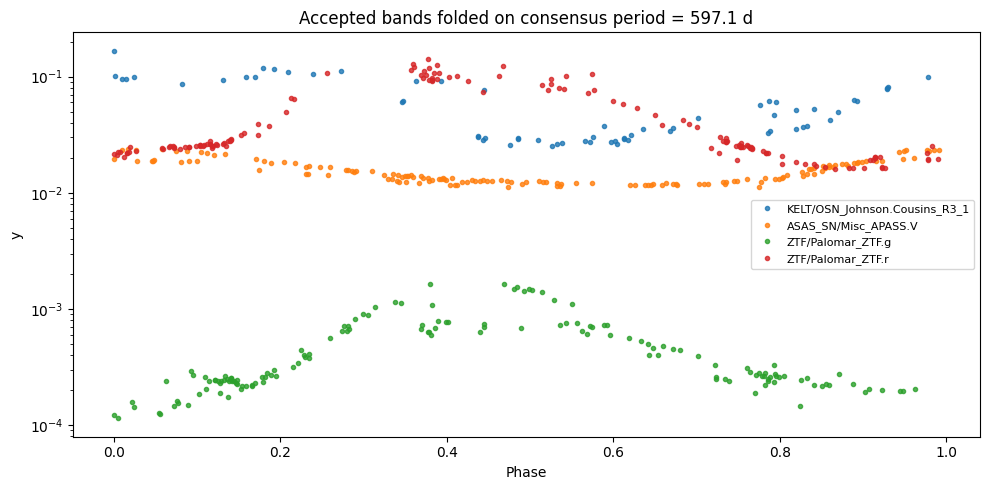

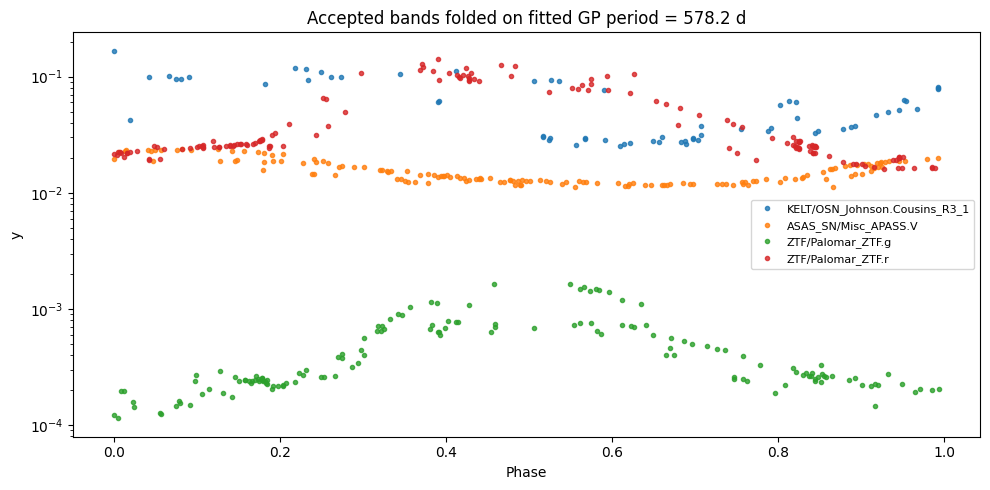

In [15]:
import numpy as np
import matplotlib.pyplot as plt

diag = lc_2d.consensus_diagnostics

# ---------------------------------------------------------------------
# 1. Period comparison: per-band LS, ACF, consensus, fitted GP
# ---------------------------------------------------------------------
per_band = diag["per_band_diagnostics"]

rows = []
for band, d in per_band.items():
    if d.get("status") != "accepted":
        continue

    rows.append({
        "band": band,
        "ls_period": d.get("dominant_period"),
        "acf_period": d.get("acf_period"),
        "selected_from": d.get("selected_from"),
    })

bands = [r["band"] for r in rows]
ls_periods = np.array([r["ls_period"] for r in rows], dtype=float)
acf_periods = np.array([r["acf_period"] for r in rows], dtype=float)

consensus_period = float(diag["final_consensus_period"])

# Fitted SM period from the shared/scientific component.
sm = lc_2d.model.sci_kernel.kernels[0]
fitted_freq = float(sm.mixture_means.detach().cpu().numpy().ravel()[0])
fitted_period = 1.0 / fitted_freq

x = np.arange(len(bands))

plt.figure(figsize=(10, 4))
plt.plot(x, ls_periods, "o-", label="LS selected period")
plt.plot(x, acf_periods, "s--", label="ACF period")
plt.axhline(consensus_period, linestyle=":", label=f"Consensus = {consensus_period:.1f} d")
plt.axhline(fitted_period, linestyle="-.", label=f"Fitted GP = {fitted_period:.1f} d")
plt.xticks(x, bands, rotation=45, ha="right")
plt.ylabel("Period [days]")
plt.title("Accepted-band period diagnostics")
plt.legend()
plt.tight_layout()
plt.show()

print("Consensus period:", consensus_period)
print("Fitted GP period:", fitted_period)
print("Fitted GP frequency:", fitted_freq)
print("Consensus bounds:", diag.get("consensus_constraint_bounds"))
print("Scale bounds:", diag.get("consensus_scale_constraint_bounds"))
print("Fitted SM scale:", sm.mixture_scales.detach().cpu().numpy().ravel()[0])


# ---------------------------------------------------------------------
# 2. Fold accepted bands on consensus period and fitted GP period
# ---------------------------------------------------------------------
def get_band_mask(lc, band_name):
    return np.asarray(lc.band.astype(str)) == str(band_name)


def phase_fold(t, period, t0=None):
    t = np.asarray(t, dtype=float)
    if t0 is None:
        t0 = np.nanmin(t)
    phase = ((t - t0) / period) % 1.0
    return phase


accepted_bands = bands

for period, label in [
    (consensus_period, f"consensus period = {consensus_period:.1f} d"),
    (fitted_period, f"fitted GP period = {fitted_period:.1f} d"),
]:
    plt.figure(figsize=(10, 5))

    for band in accepted_bands:
        mask = get_band_mask(lc_2d, band)

        t = lc_2d.xdata[mask, 0].detach().cpu().numpy()
        y = lc_2d.ydata[mask].detach().cpu().numpy()

        phase = phase_fold(t, period)

        order = np.argsort(phase)
        plt.plot(
            phase[order],
            y[order],
            ".",
            label=band,
            alpha=0.8,
        )

    plt.xlabel("Phase")
    plt.ylabel("y")
    plt.yscale('log')
    plt.title(f"Accepted bands folded on {label}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

### Diagnostic 1: Period Estimates Across the Accepted Bands

The first diagnostic compares the period estimates obtained from the individual Lomb-Scargle and autocorrelation analyses with the period inferred by the Gaussian Process model.

At first glance, the accepted bands appear to favour somewhat different periods. Some bands prefer values near 580 days, while others favour periods closer to 610 days. If interpreted literally, this could suggest that the dominant variability timescale changes systematically with wavelength.

However, the spread in the inferred periods should be interpreted with caution. Individual period estimates correspond to the locations of broad peaks in the periodograms rather than sharply defined frequencies. Consequently, differences between the peak locations can exaggerate the true level of disagreement between the bands.

The Gaussian Process solution remains close to the consensus period inferred from the accepted bands. This indicates that the dominant variability signal is shared across the wavelength range and that the blue-edge discrepancy is unlikely to arise from a fundamentally different period at the shortest wavelength.

To determine whether the apparent period differences are significant, it is necessary to examine the shapes and widths of the periodogram peaks themselves. This is the purpose of the next diagnostic.

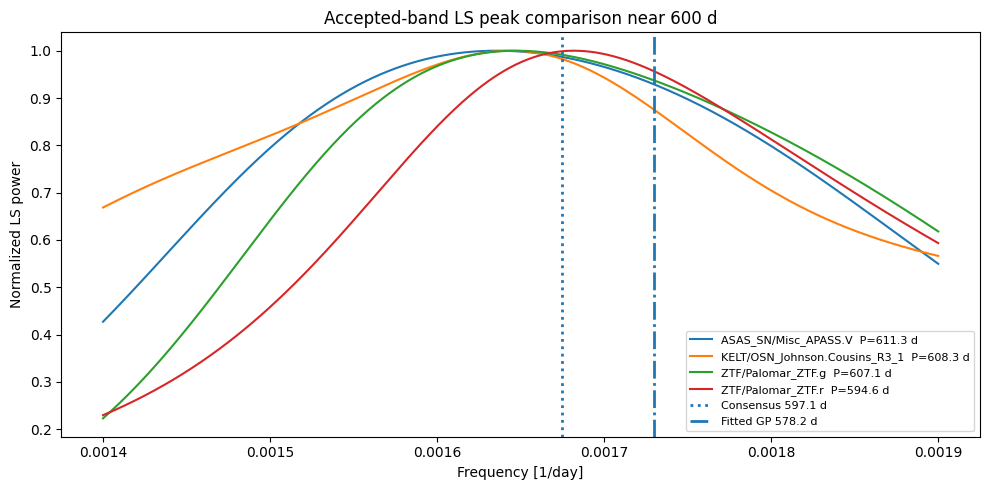

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

diag = lc_2d.consensus_diagnostics
accepted_bands = diag["accepted_bands"]

# Frequency window around the ~600 d signal.
f_min = 0.0014
f_max = 0.0019
freq = np.linspace(f_min, f_max, 5000)

plt.figure(figsize=(10, 5))

for band in accepted_bands:
    mask = np.asarray(lc_2d.band.astype(str)) == band

    t = lc_2d.xdata[mask, 0].detach().cpu().numpy()
    y = lc_2d.ydata[mask].detach().cpu().numpy()
    yerr = lc_2d.yerr[mask].detach().cpu().numpy()

    ok = np.isfinite(t) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)
    t = t[ok]
    y = y[ok]
    yerr = yerr[ok]

    if len(t) < 5:
        continue

    # Remove only a constant offset for the diagnostic.
    y0 = y - np.nanmedian(y)

    power = LombScargle(t, y0, yerr).power(freq)

    # Normalize to unit peak height so shapes/widths are comparable.
    if np.nanmax(power) > 0:
        power = power / np.nanmax(power)

    best_idx = np.nanargmax(power)
    best_freq = freq[best_idx]
    best_period = 1.0 / best_freq

    plt.plot(
        freq,
        power,
        label=f"{band}  P={best_period:.1f} d",
    )

# Reference lines
consensus_freq = float(diag["final_consensus_frequency"])
consensus_period = 1.0 / consensus_freq

sm = lc_2d.model.sci_kernel.kernels[0]
fitted_freq = float(sm.mixture_means.detach().cpu().numpy().ravel()[0])
fitted_period = 1.0 / fitted_freq

plt.axvline(
    consensus_freq,
    linestyle=":",
    linewidth=2,
    label=f"Consensus {consensus_period:.1f} d",
)
plt.axvline(
    fitted_freq,
    linestyle="-.",
    linewidth=2,
    label=f"Fitted GP {fitted_period:.1f} d",
)

plt.xlabel("Frequency [1/day]")
plt.ylabel("Normalized LS power")
plt.title("Accepted-band LS peak comparison near 600 d")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Diagnostic 2: Comparing the Shapes of the Periodogram Peaks

The normalized Lomb-Scargle periodograms provide a more informative comparison than the peak periods alone. By scaling each periodogram to unit height, the figure emphasizes the locations and widths of the dominant peaks rather than their absolute power.

The apparent wavelength dependence seen in the previous diagnostic is considerably weaker in this representation. Although the peak locations are not identical, the dominant structures overlap substantially. The accepted bands all exhibit broad maxima centred near the consensus period, and the differences between the preferred periods are small compared with the widths of the corresponding peaks.

This result is important because it changes the interpretation of the shortest-wavelength discrepancy. If the periodograms contained distinct, well-separated peaks, a wavelength-dependent period would be a plausible explanation. Instead, the periodograms indicate that the accepted bands are largely consistent with a common underlying timescale.

The broad overlap between the dominant peaks therefore supports the interpretation that the principal difficulty lies in the wavelength-dependent modelling of the variability rather than in the recovery of the period itself. The remaining diagnostics focus on how the amplitude and shape of the variability evolve with wavelength.

ZTF/Palomar_ZTF.g                   lambda=0.478350 amp_ratio=1.031 median_diff=8.5568e-05
GAIA_DR3/GAIA_GAIA3.Gbp             lambda=0.510971 amp_ratio=0.941 median_diff=-0.00040733
ASAS_SN/Misc_APASS.V                lambda=0.541917 amp_ratio=1.070 median_diff=0.00038522
GAIA_DR3/GAIA_GAIA3.G               lambda=0.621759 amp_ratio=1.003 median_diff=0.00054313
ZTF/Palomar_ZTF.r                   lambda=0.641710 amp_ratio=0.950 median_diff=0.0045013
KELT/OSN_Johnson.Cousins_R3_0       lambda=0.656115 amp_ratio=1.074 median_diff=-3.5112e-05
KELT/OSN_Johnson.Cousins_R3_1       lambda=0.656115 amp_ratio=0.856 median_diff=0.0071924
GAIA_DR3/GAIA_GAIA3.Grp             lambda=0.776902 amp_ratio=1.007 median_diff=0.0016332


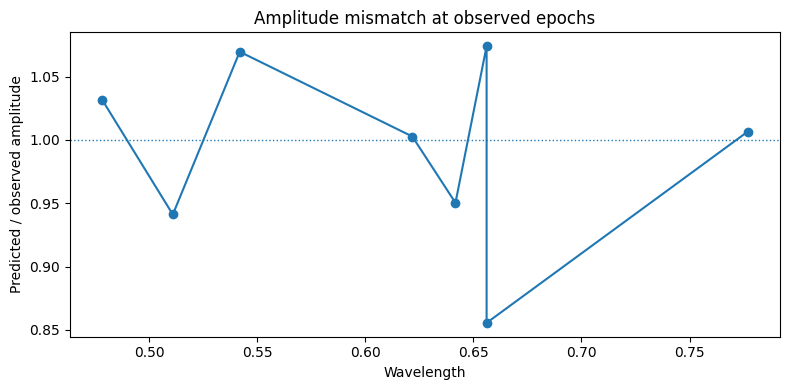

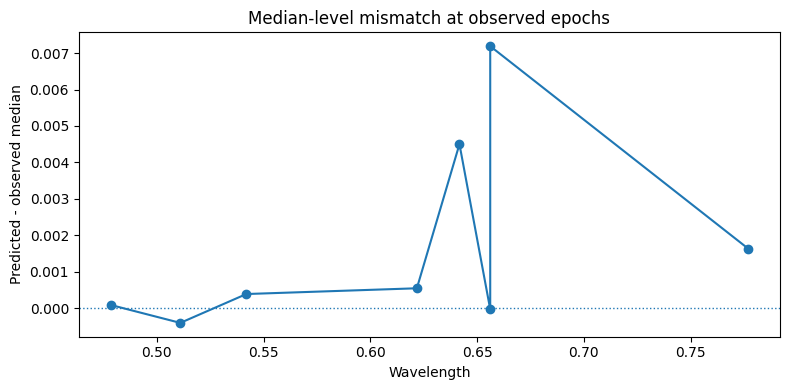

In [18]:
import numpy as np
import torch
import gpytorch
import matplotlib.pyplot as plt

def robust_amp(y, qlo=5, qhi=95):
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    return np.nanpercentile(y, qhi) - np.nanpercentile(y, qlo)

def predict_at_x(lc, x_raw):
    x = x_raw.to(
        dtype=lc._xdata_transformed.dtype,
        device=lc._xdata_transformed.device,
    )

    if lc.xtransform is not None:
        x = lc.xtransform.transform(x)

    lc._eval()
    lc.model.prediction_strategy = None

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred = lc.likelihood(lc.model(x))
        return pred.mean.detach().cpu().numpy()

band_labels = np.asarray(lc_2d.band.astype(str))
rows = []

for band in dict.fromkeys(band_labels):
    mask_np = band_labels == band
    mask = torch.as_tensor(mask_np, dtype=torch.bool, device=lc_2d.xdata.device)

    x_band = lc_2d.xdata[mask]
    y_obs = lc_2d.ydata[mask].detach().cpu().numpy()
    wl = float(torch.nanmedian(x_band[:, 1]).detach().cpu())

    y_pred_at_obs = predict_at_x(lc_2d, x_band)

    rows.append({
        "band": band,
        "wavelength": wl,
        "obs_amp": robust_amp(y_obs),
        "pred_amp": robust_amp(y_pred_at_obs),
        "obs_median": np.nanmedian(y_obs),
        "pred_median": np.nanmedian(y_pred_at_obs),
    })

rows = sorted(rows, key=lambda r: r["wavelength"])

wl = np.array([r["wavelength"] for r in rows])
amp_ratio = np.array([r["pred_amp"] / r["obs_amp"] for r in rows])
median_diff = np.array([r["pred_median"] - r["obs_median"] for r in rows])

for r in rows:
    print(
        f"{r['band']:35s} "
        f"lambda={r['wavelength']:.6f} "
        f"amp_ratio={r['pred_amp']/r['obs_amp']:.3f} "
        f"median_diff={r['pred_median']-r['obs_median']:.5g}"
    )

plt.figure(figsize=(8, 4))
plt.axhline(1.0, linestyle=":", linewidth=1)
plt.plot(wl, amp_ratio, "o-")
plt.xlabel("Wavelength")
plt.ylabel("Predicted / observed amplitude")
plt.title("Amplitude mismatch at observed epochs")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.axhline(0.0, linestyle=":", linewidth=1)
plt.plot(wl, median_diff, "o-")
plt.xlabel("Wavelength")
plt.ylabel("Predicted - observed median")
plt.title("Median-level mismatch at observed epochs")
plt.tight_layout()
plt.show()

### Diagnostic 3: Variability Amplitude as a Function of Wavelength

The previous diagnostics showed that the accepted bands are broadly consistent with a common variability timescale. We now examine whether the discrepancy arises instead from how the amplitude of the variability changes with wavelength.

For most wavelength bands, the Gaussian Process reproduces the observed variability amplitude reasonably well. The agreement is not perfect, but the predicted amplitudes generally follow the same trend seen in the observations. This indicates that the shared periodic component is successfully capturing the dominant variability behaviour across much of the wavelength range.

The shortest-wavelength band behaves differently. At approximately 0.48 μm, the model predicts a substantially larger variability amplitude than is present in the observations. This discrepancy is significantly larger than the differences seen in the neighbouring bands and immediately identifies the blue edge of the wavelength range as the principal outlier in the fit.

This result is particularly important because it points toward a wavelength-dependent modelling problem rather than a period-recovery problem. The model is capable of reproducing the correct timescale of the variability, but it is assigning too much periodic power to the shortest wavelength. Consequently, any successful improvement must address how the variability amplitude evolves with wavelength rather than simply modifying the inferred period.

The next diagnostic investigates which component of the bespoke model is responsible for this excess blue-edge amplitude.

ZTF/Palomar_ZTF.g                   lambda=0.478350 obs=0.001156 full=0.0011368 shared=0.0080398 local=0.0090526
GAIA_DR3/GAIA_GAIA3.Gbp             lambda=0.510971 obs=0.01483 full=0.014194 shared=0.026691 local=0.023663
ASAS_SN/Misc_APASS.V                lambda=0.541917 obs=0.011478 full=0.012248 shared=0.014835 local=0.0052498
GAIA_DR3/GAIA_GAIA3.G               lambda=0.621759 obs=0.17363 full=0.16955 shared=0.17386 local=0.014884
ZTF/Palomar_ZTF.r                   lambda=0.641710 obs=0.093629 full=0.088226 shared=0.098686 local=0.033211
KELT/OSN_Johnson.Cousins_R3_0       lambda=0.656115 obs=0.096151 full=0.10471 shared=0.079684 local=0.037606
KELT/OSN_Johnson.Cousins_R3_1       lambda=0.656115 obs=0.084026 full=0.072281 shared=0.058177 local=0.026186
GAIA_DR3/GAIA_GAIA3.Grp             lambda=0.776902 obs=0.62414 full=0.62554 shared=0.62462 local=0.010916


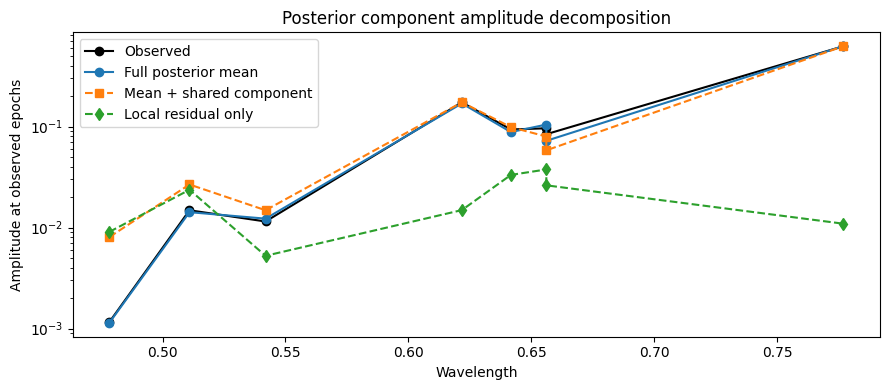

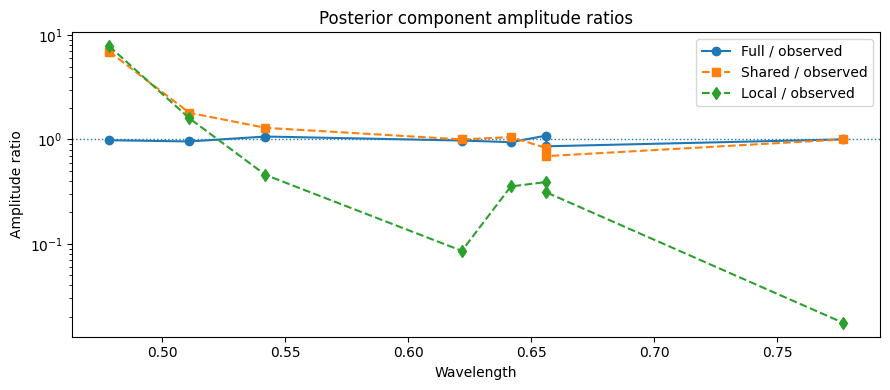

In [19]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def robust_amp(y, qlo=5, qhi=95):
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    return np.nanpercentile(y, qhi) - np.nanpercentile(y, qlo)

def dense(k):
    return k.to_dense() if hasattr(k, "to_dense") else k.evaluate()

def additive_component_posterior_means(lc, x_star):
    model = lc.model
    model.eval()

    train_x = model.train_inputs[0]
    train_y = model.train_targets

    x_star = x_star.to(dtype=train_x.dtype, device=train_x.device)

    if lc.xtransform is not None:
        x_star = lc.xtransform.transform(x_star)

    with torch.no_grad():
        mean_train = model.mean_module(train_x)
        mean_star = model.mean_module(x_star)

        K_train = dense(model.covar_module(train_x))

        # Use the same fixed observational noise used by the Lightcurve.
        noise = lc._yerr_transformed.to(dtype=train_x.dtype, device=train_x.device) ** 2
        K_train = K_train + torch.diag(noise)

        # Small numerical jitter.
        K_train = K_train + 1.0e-6 * torch.eye(
            K_train.shape[0],
            dtype=K_train.dtype,
            device=K_train.device,
        )

        alpha = torch.linalg.solve(K_train, train_y - mean_train)

        K_shared_star_train = dense(model.shared_component(x_star, train_x))
        K_local_star_train = dense(model.local_component(x_star, train_x))

        shared_dev = K_shared_star_train @ alpha
        local_dev = K_local_star_train @ alpha

        full_mean = mean_star + shared_dev + local_dev
        shared_mean = mean_star + shared_dev
        local_only = local_dev

    return (
        full_mean.detach().cpu().numpy(),
        shared_mean.detach().cpu().numpy(),
        local_only.detach().cpu().numpy(),
    )

band_labels = np.asarray(lc_2d.band.astype(str))
rows = []

for band in dict.fromkeys(band_labels):
    mask_np = band_labels == band
    mask = torch.as_tensor(mask_np, dtype=torch.bool, device=lc_2d.xdata.device)

    x_band = lc_2d.xdata[mask]
    y_obs = lc_2d.ydata[mask].detach().cpu().numpy()
    wl = float(torch.nanmedian(x_band[:, 1]).detach().cpu())

    y_full, y_shared, y_local = additive_component_posterior_means(lc_2d, x_band)

    rows.append({
        "band": band,
        "wavelength": wl,
        "obs_amp": robust_amp(y_obs),
        "full_amp": robust_amp(y_full),
        "shared_amp": robust_amp(y_shared),
        "local_amp": robust_amp(y_local),
    })

rows = sorted(rows, key=lambda r: r["wavelength"])

for r in rows:
    print(
        f"{r['band']:35s} "
        f"lambda={r['wavelength']:.6f} "
        f"obs={r['obs_amp']:.5g} "
        f"full={r['full_amp']:.5g} "
        f"shared={r['shared_amp']:.5g} "
        f"local={r['local_amp']:.5g}"
    )

wl = np.array([r["wavelength"] for r in rows])
obs_amp = np.array([r["obs_amp"] for r in rows])
full_amp = np.array([r["full_amp"] for r in rows])
shared_amp = np.array([r["shared_amp"] for r in rows])
local_amp = np.array([r["local_amp"] for r in rows])

plt.figure(figsize=(9, 4))
plt.plot(wl, obs_amp, "ko-", label="Observed")
plt.plot(wl, full_amp, "o-", label="Full posterior mean")
plt.plot(wl, shared_amp, "s--", label="Mean + shared component")
plt.plot(wl, local_amp, "d--", label="Local residual only")
plt.xlabel("Wavelength")
plt.ylabel("Amplitude at observed epochs")
plt.title("Posterior component amplitude decomposition")
plt.legend()
plt.yscale("log")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.axhline(1.0, linestyle=":", linewidth=1)
plt.plot(wl, full_amp / obs_amp, "o-", label="Full / observed")
plt.plot(wl, shared_amp / obs_amp, "s--", label="Shared / observed")
plt.plot(wl, local_amp / obs_amp, "d--", label="Local / observed")
plt.xlabel("Wavelength")
plt.ylabel("Amplitude ratio")
plt.title("Posterior component amplitude ratios")
plt.legend()
plt.yscale("log")
plt.tight_layout()
plt.show()

### Diagnostic 4: Identifying the Source of the Blue-Edge Excess

The previous diagnostic demonstrated that the shortest-wavelength band exhibits substantially more predicted variability than is present in the observations. The purpose of the present diagnostic is to determine which part of the bespoke model is responsible for this behaviour.

The decomposition separates the prediction into contributions from the full model, the shared periodic component, and the wavelength-local residual component. If the residual term were solely responsible for the discrepancy, the excess variability would disappear when examining the shared component in isolation. Conversely, if the shared component itself overpredicts the variability amplitude, then the problem originates in the wavelength-dependent structure of the periodic model.

The decomposition shows that the shared periodic component already assigns excessive variability amplitude to the shortest wavelength. The local residual component does not create this problem. Instead, it partially compensates for it. In effect, the residual term is being used by the optimizer to counteract an overprediction produced by the shared wavelength-dependent component.

This result substantially changes the interpretation of the fit. The remaining discrepancy is not primarily a consequence of the additional flexibility introduced by the residual model. Rather, it reflects how the shared periodic variability is allowed to evolve with wavelength. The shortest-wavelength band therefore exposes a limitation of the wavelength kernel associated with the shared scientific component.

The next diagnostic examines the fitted parameters of the shared wavelength kernel directly in order to determine whether the model is attempting to vary too rapidly with wavelength.

In [28]:
print("Shared component:")
print(lc_2d.model.shared_component)

print("\nShared wavelength outputscale:")
print(
    lc_2d.model.shared_component.kernels[1]
    .outputscale.detach().cpu().numpy()
)

print("\nShared wavelength lengthscale:")
print(
    lc_2d.model.shared_component.kernels[1]
    .base_kernel.lengthscale.detach().cpu().numpy()
)

print("\nShared wavelength lengthscale constraint:")
print(
    lc_2d.model.shared_component.kernels[1]
    .base_kernel.raw_lengthscale_constraint
)

diag = lc_2d.consensus_diagnostics

print("\nConsensus constraints:")
print("consensus_constraints_applied:", diag.get("consensus_constraints_applied"))
print("consensus_constraint_target_key:", diag.get("consensus_constraint_target_key"))
print("consensus_constraint_bounds:", diag.get("consensus_constraint_bounds"))
print("consensus_scale_constraint_target_key:", diag.get("consensus_scale_constraint_target_key"))
print("consensus_scale_constraint_bounds:", diag.get("consensus_scale_constraint_bounds"))

sm = lc_2d.model.shared_component.kernels[0]

print("\nSpectral-mixture kernel:")
print("SM means constraint:", sm.raw_mixture_means_constraint)
print("SM scales constraint:", sm.raw_mixture_scales_constraint)
print("SM mean:", sm.mixture_means.detach().cpu().numpy())
print("SM period:", 1.0 / sm.mixture_means.detach().cpu().numpy())
print("SM scale:", sm.mixture_scales.detach().cpu().numpy())

Shared component:
ProductKernel(
  (kernels): ModuleList(
    (0): SpectralMixtureKernel(
      (raw_mixture_scales_constraint): Interval(1.000E-06, 3.395E-05)
      (raw_mixture_means_constraint): Interval(1.675E-03, 1.720E-03)
      (raw_mixture_weights_constraint): Positive()
    )
    (1): ScaleKernel(
      (base_kernel): RBFKernel(
        (raw_lengthscale_constraint): Interval(2.239E-01, 2.986E+00)
      )
      (raw_outputscale_constraint): Positive()
    )
  )
)

Shared wavelength outputscale:
3.703560941496016

Shared wavelength lengthscale:
[[0.25311279]]

Shared wavelength lengthscale constraint:
Interval(2.239E-01, 2.986E+00)

Consensus constraints:
consensus_constraints_applied: True
consensus_constraint_target_key: shared_component.kernels.0.mixture_means
consensus_constraint_bounds: [0.0016747703943814157, 0.001719792438843588]
consensus_scale_constraint_target_key: shared_component.kernels.0.mixture_scales
consensus_scale_constraint_bounds: [1e-06, 3.3945628332250035e-

### Diagnostic 5: Behaviour of the Shared Wavelength Kernel

The previous diagnostic indicated that the excess variability at the shortest wavelength originates primarily from the shared periodic component. To understand why this occurs, we now examine the fitted parameters of the shared wavelength kernel directly.

The fitted wavelength lengthscale lies very close to the lower bound permitted by the model. This behaviour indicates that the optimizer is attempting to make the shared periodic variability change as rapidly with wavelength as the constraints allow. In other words, the model prefers a wavelength dependence that is more localized than the current parameterization permits.

This observation is significant because it provides a direct explanation for the blue-edge behaviour. When the wavelength kernel becomes highly localized, the shortest-wavelength band is effectively allowed to develop variability properties that differ substantially from those of its neighbours. The resulting flexibility manifests itself as excess predicted amplitude at the blue edge of the wavelength range.

At the same time, the fitted solution does not sit exactly on the constraint boundary. The model still requires substantial wavelength coherence, indicating that the variability pattern remains strongly shared across the different bands. The issue is therefore not a complete breakdown of wavelength coupling, but rather an imbalance between global coherence and local flexibility.

These diagnostics suggest a natural next experiment. If the shortest-wavelength discrepancy arises because the shared wavelength kernel is allowed to vary too rapidly, then increasing the minimum wavelength lengthscale should enforce stronger coherence between neighbouring bands and reduce the tendency toward blue-edge amplitude inflation.

The following fit therefore modifies the lower bound on the shared wavelength lengthscale while leaving the remainder of the model unchanged.

## Final Interpretation and Preferred Model Configuration

The preceding diagnostics showed that the principal limitation of the bespoke model was not the recovery of the dominant variability timescale, but rather the behaviour of the shared wavelength kernel at the blue edge of the wavelength range. The shortest-wavelength band exhibited excess predicted variability because the shared periodic component was allowed to vary too rapidly with wavelength.

To address this issue, the lower bound on the shared wavelength lengthscale was increased while leaving the remainder of the model unchanged. This modification enforces stronger coherence between neighbouring wavelengths and prevents the shared periodic component from developing excessively localized behaviour at the edge of the wavelength domain.

The resulting fit represents a useful compromise between flexibility and stability. The shortest-wavelength band is reproduced more accurately than in the original wavelength-dependent model, while the dominant period remains consistent with the consensus solution derived from the accepted bands. At the same time, the model retains sufficient flexibility to accommodate genuine wavelength-dependent variability rather than forcing all bands to behave identically.

Experiments with even stronger wavelength-coherence constraints demonstrated that additional smoothing is not necessarily beneficial. Increasing the lower bound too aggressively improved some aspects of the fit while simultaneously degrading others and could lead to visibly pathological solutions. The preferred configuration therefore corresponds to a moderate increase in wavelength coherence rather than the strongest possible constraint.

Several broader conclusions emerge from this investigation:

1. The consensus workflow successfully identifies a stable dominant variability timescale near 600 days across the accepted bands.
2. The primary challenge in this source is not determining the period, but describing how the variability properties evolve with wavelength.
3. The shortest-wavelength band is the dominant outlier and serves as a sensitive diagnostic of the wavelength-dependent structure of the model.
4. Additional spectral-mixture components can improve the apparent fit quality but also increase the risk of overfitting.
5. A bespoke model combining a shared periodic component with a constrained wavelength-local residual component provides a more physically plausible description of the data than either the baseline model or an unconstrained increase in model complexity.

Taken together, these results suggest that careful control of wavelength-dependent flexibility is more effective than simply increasing the number of periodic components. The dominant variability appears to be broadly shared across the wavelength range, while the remaining discrepancies arise primarily from how that variability is coupled between bands.

# Appendix: Alternative Mean Functions

The main body of this notebook focused on the consensus-constrained wavelength-dependent Gaussian Process models and the investigation of the shortest-wavelength discrepancy. Throughout that analysis, a quadratic mean function was used as the baseline choice because it provided a flexible but relatively simple description of long-term trends in the light curves.

The experiments collected in this appendix explore alternative mean-function parameterizations. These tests were performed to assess whether some of the residual discrepancies could be attributed to the assumed mean model rather than to the covariance structure of the Gaussian Process itself.

The results presented here should be viewed as supplementary investigations rather than as part of the primary modelling workflow. Although different mean functions can alter the detailed appearance of the fits, the principal conclusions of the notebook remain unchanged: the dominant variability timescale is robustly recovered by the consensus analysis, and the most significant modelling challenge arises from the wavelength-dependent behaviour of the shortest-wavelength band.


## Dust-Inspired Mean Function

The first alternative considered here replaces the quadratic mean function with a dust-inspired mean model. The motivation is that the observed flux distribution changes systematically with wavelength, and a physically motivated mean function might capture some of this behaviour more naturally than a generic polynomial trend.

This experiment does not modify the covariance structure of the Gaussian Process or the consensus-derived period constraints. Consequently, any changes in the resulting fits can be attributed primarily to the choice of mean function rather than to differences in the inferred variability timescale.

/usr/local/lib/python3.12/dist-packages/pgmuvi/preprocess/quality.py:286: UserWarning: median_cadence is zero (many duplicate timestamps present). Falling back to the mean of positive gaps only for nyquist_period, nyquist_frequency, and duty_cycle; results may not be robust.
  metrics = compute_sampling_metrics(t, y, yerr)
/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:1417: UserWarning: Skipping band λ=0.4849115014076233 due to poor temporal sampling: Too few points: 12 < 15, Large gap: 702.00 (94.9% of baseline) > 30% threshold, Lightcurve contains large numbers of points with identical timestamps. Determining sampling quality using mean cadence instead of median; result may not be robust.
  return cls(xdata=x, ydata=y, yerr=yerr, **kwargs)
/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:1417: UserWarning: Skipping band λ=0.6201199889183044 due to poor temporal sampling: Large gap: 698.00 (47.7% of baseline) > 30% threshold
  return cls(xdata=x, ydata=y, ye

[consensus] accepted bands: ['KELT/OSN_Johnson.Cousins_R3_1', 'ASAS_SN/Misc_APASS.V', 'ZTF/Palomar_ZTF.g', 'ZTF/Palomar_ZTF.r']
[consensus] rejected bands: ['KELT/OSN_Johnson.Cousins_R3_0', 'GAIA_DR3/GAIA_GAIA3.Gbp', 'GAIA_DR3/GAIA_GAIA3.G', 'GAIA_DR3/GAIA_GAIA3.Grp']
[consensus] band=KELT/OSN_Johnson.Cousins_R3_0 rejected: ls_acf_disagreement
[consensus] band=KELT/OSN_Johnson.Cousins_R3_1 dominant_period=609.429 dominant_frequency=0.00164088 acf_status=harmonic harmonic_order=4
[consensus] band=ASAS_SN/Misc_APASS.V dominant_period=597.097 dominant_frequency=0.00167477 acf_status=agreement harmonic_order=1
[consensus] band=GAIA_DR3/GAIA_GAIA3.Gbp rejected: duty_cycle (0.0151 < 0.131)
[consensus] band=GAIA_DR3/GAIA_GAIA3.G rejected: duty_cycle (0.0149 < 0.131)
[consensus] band=GAIA_DR3/GAIA_GAIA3.Grp rejected: duty_cycle (0.0151 < 0.131)
[consensus] band=ZTF/Palomar_ZTF.g dominant_period=581.466 dominant_frequency=0.00171979 acf_status=agreement harmonic_order=1
[consensus] band=ZTF/Pal

100%|██████████| 500/500 [01:08<00:00,  7.28it/s]
/usr/local/lib/python3.12/dist-packages/gpytorch/likelihoods/gaussian_likelihood.py:350: GPInputWarning: You have passed data through a FixedNoiseGaussianLikelihood that did not match the size of the fixed noise, *and* you did not specify noise. This is treated as a no-op.
  warnings.warn(


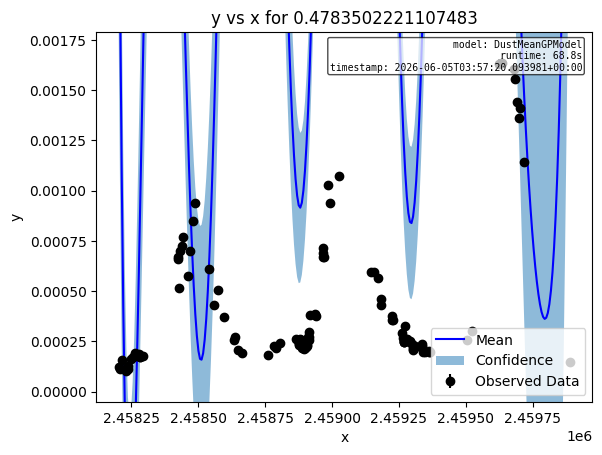

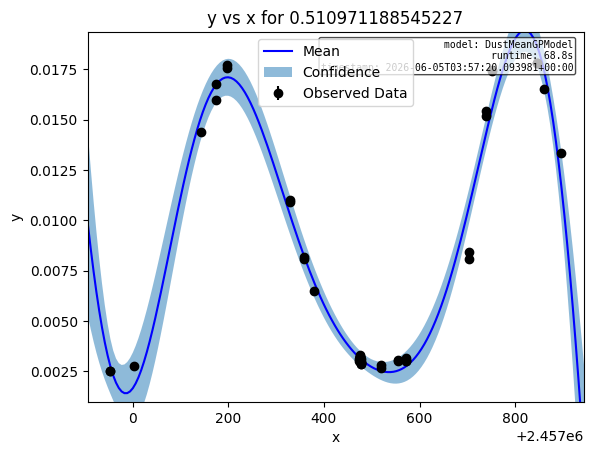

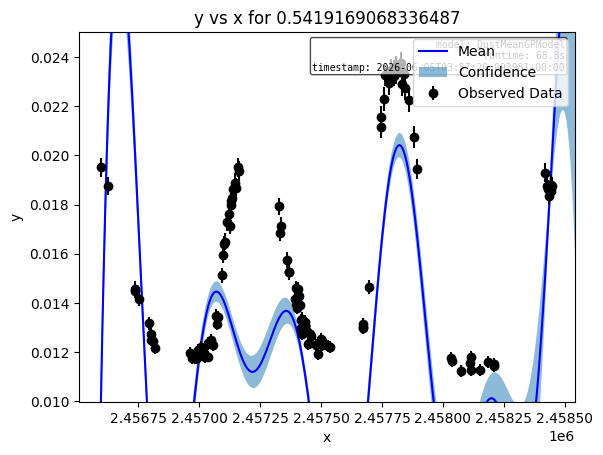

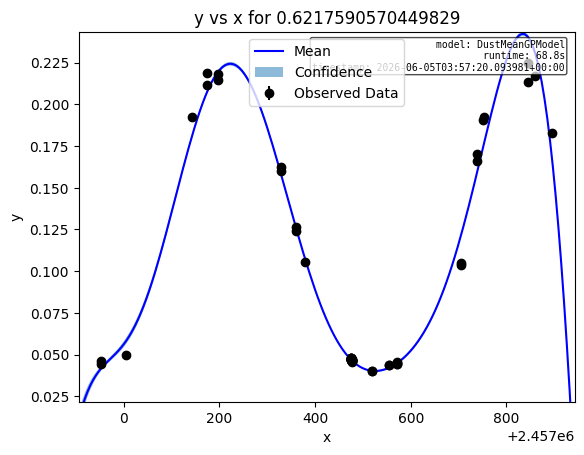

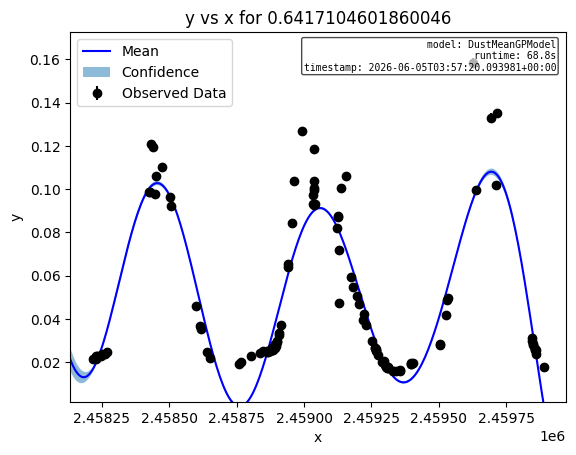

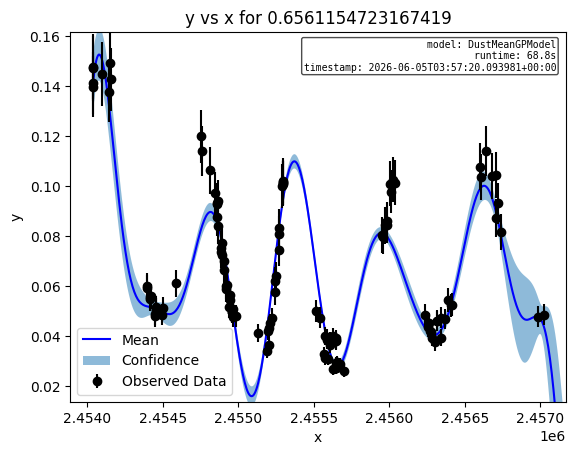

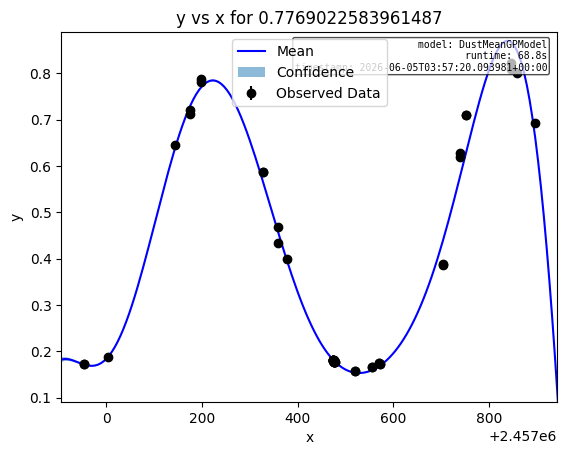

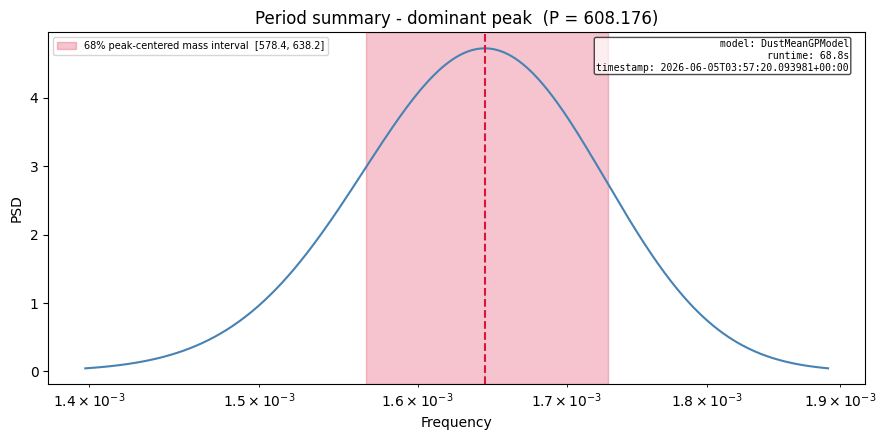

PERIOD SUMMARY
  Model name          : N/A
  Method              : spectral_mixture_psd_peak
  Backend             : separable_2d
  Kernel family       : ProductKernel
  Time-kernel family  : SpectralMixtureKernel
  Stochastic bg       : False
  Interval definition : peak_centered_68pct_mass_interval
  Dominant period     : 608.176
  Dominant frequency  : 0.00164426
  Peaks detected      : 1
  Peaks analyzed      : 1
  Peaks requested     : N/A
  Notes               : Separable 2D model (separable_2d backend): period summary derived from the time kernel (SpectralMixtureKernel) only.  The wavelength kernel does not contribute to this period determination.  Spectral-mixture model (spectral_mixture backend).  Periods are derived from peaks of the SUMMED PSD on a frequency grid — this is the literature-comparable output.  The component periods/frequencies listed in the kernel component diagnostics section are direct kernel hyperparameter values and are for diagnostic purposes only; they ar

In [29]:
lc_2d = Lightcurve.from_csv("10131+3049.csv", max_samples_per_band=120, max_samples=1000, check_sampling=True)
lc_2d.double()
fit_result = lc_2d.fit(
    model="2DDustMean",
    time_kernel_type="spectral_mixture",
    wavelength_kernel_type="rbf",
    # mean_module="quad",
    training_iter=TRAINING_ITER,
    num_mixtures=NUM_MIXTURES,
    constraint_set=CONSTRAINT_SET,
    cuda=CUDA,
    use_mls_init=False,
    use_best_band_init=False,
    fit_strategy="consensus",
    use_acf=True,
    use_gp_validation=False,
    min_consensus_inliers=2,
    outlier_sigma=2.0,
    consensus_dedup_rtol=0.02,
    constrain_consensus=True,
    consensus_width_factor=1.0,
    consensus_frequency_k=1.0,
    consensus_scale_max_factor=0.05,
    lr=0.05,
    stopavg=30,
    verbose=True,
)
lc_2d.plot(annotate_provenance=True, provenance_location="upper right",)
lc_2d.plot_period_summary(annotate_provenance=True, provenance_location="upper right", log_y=False)
period_summary = lc_2d.get_period_summary()
print(period_summary.to_text(max_peaks_to_show=2))
print(lc_2d.fit_history_to_text())
print(lc_2d.print_fit_history_summary(print_summary=False))
report = lc_2d.generate_reproducibility_report(
    latest_only=False,
    include_history=True,
    include_configurations=True,
    include_environment=True,
)
print(report)

## Interpretation of the Dust-Inspired Mean Function

The dust-inspired mean function produces a solution that is broadly consistent with the behaviour identified in the main body of the notebook. The consensus procedure selects a similar set of high-quality bands, and the resulting Gaussian Process recovers a dominant variability timescale near 600 days.

The overall appearance of the fit remains similar to that obtained using the quadratic mean function. The principal variability pattern is reproduced successfully, and the same wavelength-dependent trends remain visible. In particular, the shortest-wavelength band continues to represent the most challenging part of the dataset.

Although the detailed fit differs from the baseline model, the scientific interpretation is largely unchanged. The dominant variability remains associated with a long-period modulation near 600 days, and the principal modelling challenge continues to involve the wavelength dependence of the variability rather than the recovery of the period itself.

This result suggests that the conclusions of the main analysis are reasonably robust to the adoption of a physically motivated alternative mean function.

## Power-Law Mean Function

As a second sensitivity test, the quadratic mean function is replaced with a power-law parameterization. This provides a substantially different description of the wavelength dependence of the mean flux level while leaving the Gaussian Process covariance structure unchanged.

The purpose of this experiment is not to identify a preferred physical model for the mean emission, but rather to determine whether the conclusions reached in the main analysis depend strongly on the assumed mean-function parameterization.

/usr/local/lib/python3.12/dist-packages/pgmuvi/preprocess/quality.py:286: UserWarning: median_cadence is zero (many duplicate timestamps present). Falling back to the mean of positive gaps only for nyquist_period, nyquist_frequency, and duty_cycle; results may not be robust.
  metrics = compute_sampling_metrics(t, y, yerr)
/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:1417: UserWarning: Skipping band λ=0.4849115014076233 due to poor temporal sampling: Too few points: 12 < 15, Large gap: 702.00 (94.9% of baseline) > 30% threshold, Lightcurve contains large numbers of points with identical timestamps. Determining sampling quality using mean cadence instead of median; result may not be robust.
  return cls(xdata=x, ydata=y, yerr=yerr, **kwargs)
/usr/local/lib/python3.12/dist-packages/pgmuvi/lightcurve.py:1417: UserWarning: Skipping band λ=0.6201199889183044 due to poor temporal sampling: Large gap: 698.00 (47.7% of baseline) > 30% threshold
  return cls(xdata=x, ydata=y, ye

[consensus] accepted bands: ['KELT/OSN_Johnson.Cousins_R3_0', 'ASAS_SN/Misc_APASS.V', 'ZTF/Palomar_ZTF.g']
[consensus] rejected bands: ['KELT/OSN_Johnson.Cousins_R3_1', 'GAIA_DR3/GAIA_GAIA3.Gbp', 'GAIA_DR3/GAIA_GAIA3.G', 'GAIA_DR3/GAIA_GAIA3.Grp', 'ZTF/Palomar_ZTF.r']
[consensus] band=KELT/OSN_Johnson.Cousins_R3_0 dominant_period=585.686 dominant_frequency=0.0017074 acf_status=harmonic harmonic_order=2
[consensus] band=KELT/OSN_Johnson.Cousins_R3_1 rejected: ls_acf_disagreement
[consensus] band=ASAS_SN/Misc_APASS.V dominant_period=597.097 dominant_frequency=0.00167477 acf_status=agreement harmonic_order=1
[consensus] band=GAIA_DR3/GAIA_GAIA3.Gbp rejected: duty_cycle (0.0151 < 0.103)
[consensus] band=GAIA_DR3/GAIA_GAIA3.G rejected: duty_cycle (0.0149 < 0.103)
[consensus] band=GAIA_DR3/GAIA_GAIA3.Grp rejected: duty_cycle (0.0151 < 0.103)
[consensus] band=ZTF/Palomar_ZTF.g dominant_period=581.466 dominant_frequency=0.00171979 acf_status=agreement harmonic_order=1
[consensus] band=ZTF/Palo

100%|██████████| 500/500 [01:04<00:00,  7.80it/s]
/usr/local/lib/python3.12/dist-packages/gpytorch/likelihoods/gaussian_likelihood.py:350: GPInputWarning: You have passed data through a FixedNoiseGaussianLikelihood that did not match the size of the fixed noise, *and* you did not specify noise. This is treated as a no-op.
  warnings.warn(


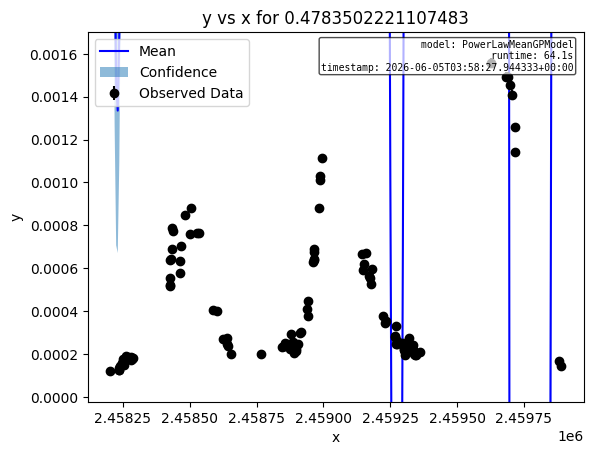

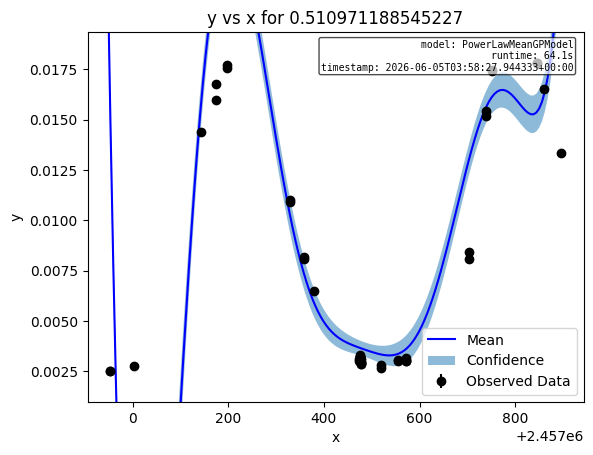

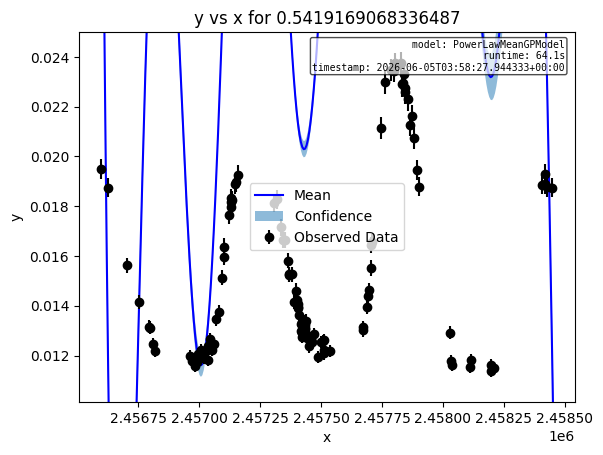

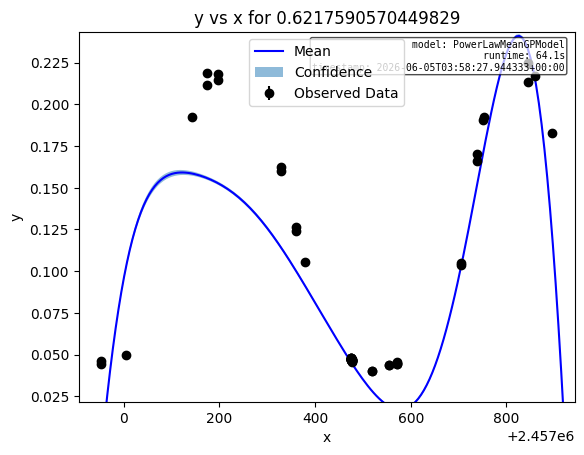

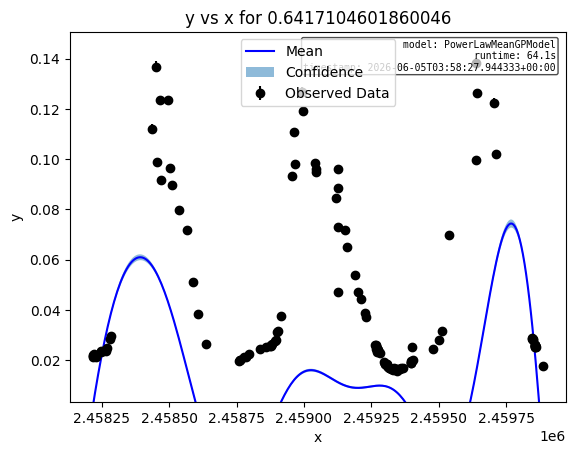

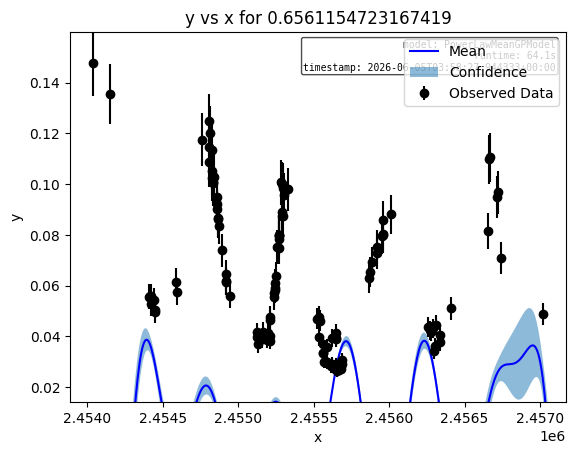

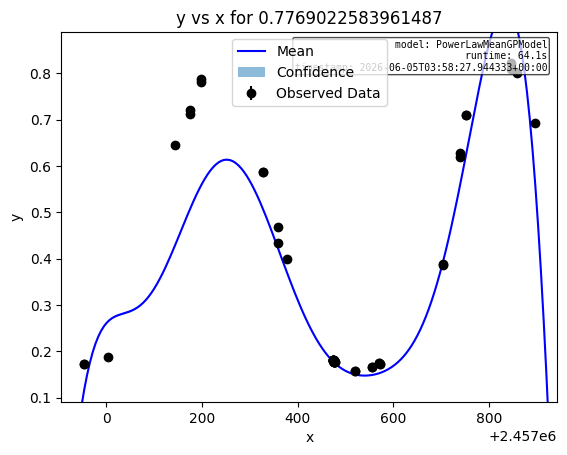

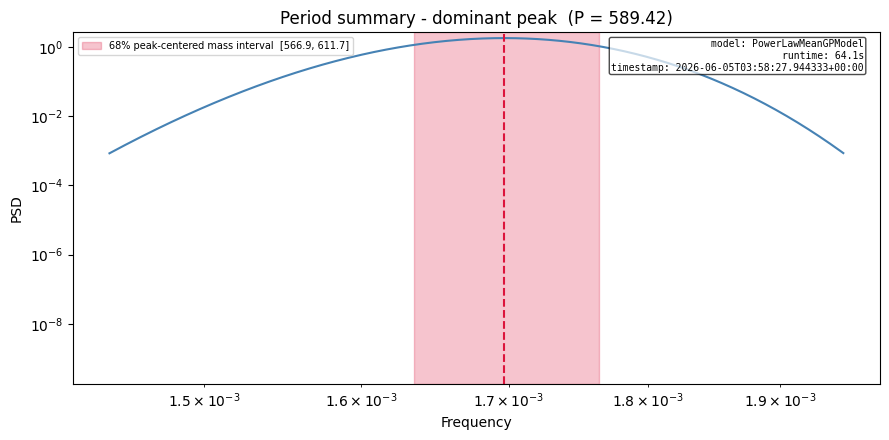

PERIOD SUMMARY
  Model name          : N/A
  Method              : spectral_mixture_psd_peak
  Backend             : separable_2d
  Kernel family       : ProductKernel
  Time-kernel family  : SpectralMixtureKernel
  Stochastic bg       : False
  Interval definition : peak_centered_68pct_mass_interval
  Dominant period     : 589.42
  Dominant frequency  : 0.00169658
  Peaks detected      : 1
  Peaks analyzed      : 1
  Peaks requested     : N/A
  Notes               : Separable 2D model (separable_2d backend): period summary derived from the time kernel (SpectralMixtureKernel) only.  The wavelength kernel does not contribute to this period determination.  Spectral-mixture model (spectral_mixture backend).  Periods are derived from peaks of the SUMMED PSD on a frequency grid — this is the literature-comparable output.  The component periods/frequencies listed in the kernel component diagnostics section are direct kernel hyperparameter values and are for diagnostic purposes only; they are

In [30]:
lc_2d = Lightcurve.from_csv("10131+3049.csv", max_samples_per_band=120, max_samples=1000, check_sampling=True)
lc_2d.double()
fit_result = lc_2d.fit(
    model="2DPowerLawMean",
    time_kernel_type="spectral_mixture",
    wavelength_kernel_type="rbf",
    # mean_module="quad",
    training_iter=TRAINING_ITER,
    num_mixtures=NUM_MIXTURES,
    constraint_set=CONSTRAINT_SET,
    cuda=CUDA,
    use_mls_init=False,
    use_best_band_init=False,
    fit_strategy="consensus",
    use_acf=True,
    use_gp_validation=False,
    min_consensus_inliers=3,
    outlier_sigma=2.0,
    consensus_dedup_rtol=0.02,
    constrain_consensus=True,
    consensus_width_factor=1.0,
    consensus_frequency_k=1.0,
    consensus_scale_max_factor=0.05,
    lr=0.05,
    stopavg=30,
    verbose=True,
)
lc_2d.plot(annotate_provenance=True, provenance_location="upper right",)
lc_2d.plot_period_summary(annotate_provenance=True, provenance_location="upper right",)
period_summary = lc_2d.get_period_summary()
print(period_summary.to_text(max_peaks_to_show=2))
print(lc_2d.fit_history_to_text())
print(lc_2d.print_fit_history_summary(print_summary=False))
report = lc_2d.generate_reproducibility_report(
    latest_only=False,
    include_history=True,
    include_configurations=True,
    include_environment=True,
)
print(report)

## Interpretation of the Power-Law Mean Function

The power-law mean function produces a noticeably different consensus solution from the dust-inspired and quadratic mean models. The accepted-band set changes, the consensus frequency shifts, and the resulting Gaussian Process converges to a dominant period near 590 days rather than the approximately 600-day solution obtained elsewhere in the notebook.

Despite this shift, the inferred period remains within the broad range already indicated by the individual-band period analyses. Earlier diagnostics showed that the accepted periodograms possess substantial overlap and do not define a single sharply localized period. Consequently, the difference between the approximately 590-day and approximately 600-day solutions should not be over-interpreted.

The sensitivity of the recovered period to the assumed mean function is nevertheless informative. It demonstrates that the detailed balance between long-term trends and periodic variability can influence which bands survive the consensus-selection procedure and therefore affect the final consensus frequency.

Even so, the overall scientific picture remains unchanged. The source is consistently described by a dominant long-period variability component of roughly six hundred days, and the shortest-wavelength band remains the primary challenge for the wavelength-dependent modelling. The appendix experiments therefore illustrate that the exact numerical period can depend somewhat on modelling assumptions, while the broader conclusions of the notebook remain stable.